# 4 空间填充设计

> **图 4.1** 基于 7 个聚类点的设计方案，同时展示了沃罗诺伊区域。

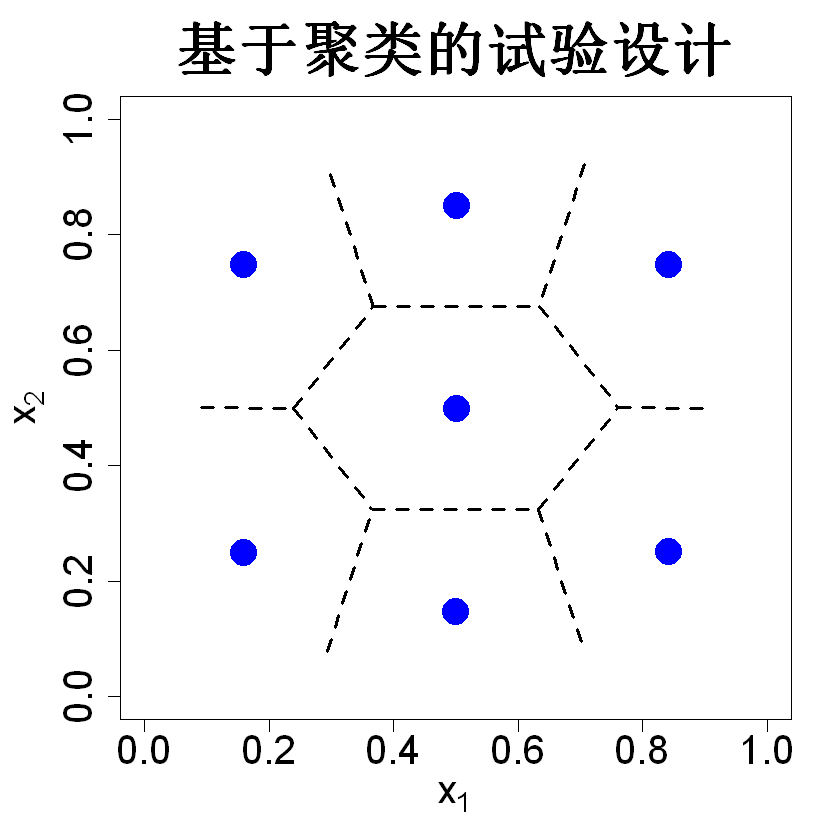

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.1-D.csv")||!file.exists("data/4.1-vor.rds")){
  p=2;n=7
  N=n*p*10000
  library(mined)
  library(SFDesign)
  X=Lattice(10000,2)
  a2=kmeans(X,centers=n,iter.max=1000,nstart=100)
  D2=a2$centers
  cluster.error(D2)
  D=clustering.design(n,p)$design
  cluster.error(D)
  D=clustering.design(n,p,D.ini=D2)$design
  cluster.error(D)
  library(deldir)
  vor=deldir(D[,1],D[,2])
  m.D=cbind(D)
  colnames(m.D)=c("D.1","D.2")
  write.csv(m.D,file="data/4.1-D.csv",row.names=FALSE)
  saveRDS(vor,file="data/4.1-vor.rds")
}

df_D=read.csv("data/4.1-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
vor=readRDS("data/4.1-vor.rds")

options(repr.plot.width=7,repr.plot.height=7)
par(mar=c(5,5,4,2))
plot(D,xlim=c(0,1),ylim=c(0,1),main="基于聚类的试验设计",xlab=expression(x[1]),ylab=expression(x[2]),cex.main=3,cex.lab=2,cex.axis=2,pch=16,col="blue",cex=3)
library(deldir)
plot.deldir(vor,add=TRUE,wlines="tess",xlim=c(0,1),ylim=c(0,1),showpoints=FALSE,lwd=3)

> **图 4.2** 7 点极小极大设计。

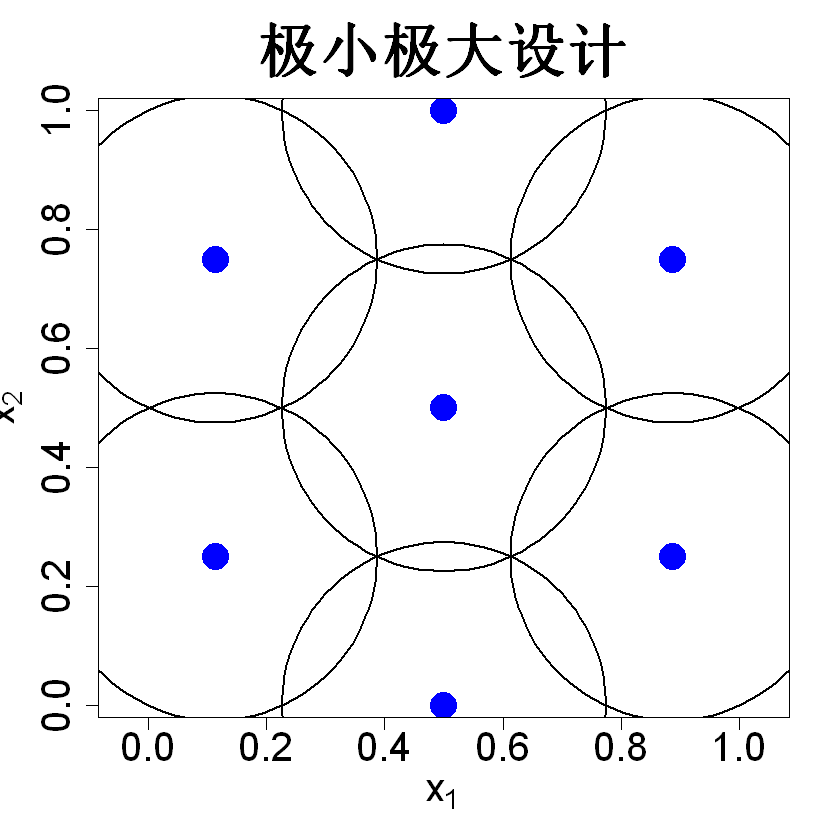

In [3]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.2-D.csv")){
  p=2;n=7
  DmM=matrix(c(.5,.5,.5,0,.5,1,1/3-1/12*sqrt(7),.25,1/3-1/12*sqrt(7),.75,2/3+1/12*sqrt(7),.25,2/3+1/12*sqrt(7),.75),nrow=7,ncol=2,byrow=TRUE)
  m.D=cbind(DmM)
  colnames(m.D)=c("D.1","D.2")
  write.csv(m.D,file="data/4.2-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.2-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])

options(repr.plot.width=7,repr.plot.height=7)
library(MASS)
eqscplot(D[,1],D[,2],xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2,main="极小极大设计")
library(plotrix)
for(i in 1:7) draw.circle(D[i,1],D[i,2],radius=1/6*(sqrt(7)-1),lwd=2)

> **图 4.3** 两组包含 7 个样本点的设计方案，二者分离距离相同，但极大极小指标不同。

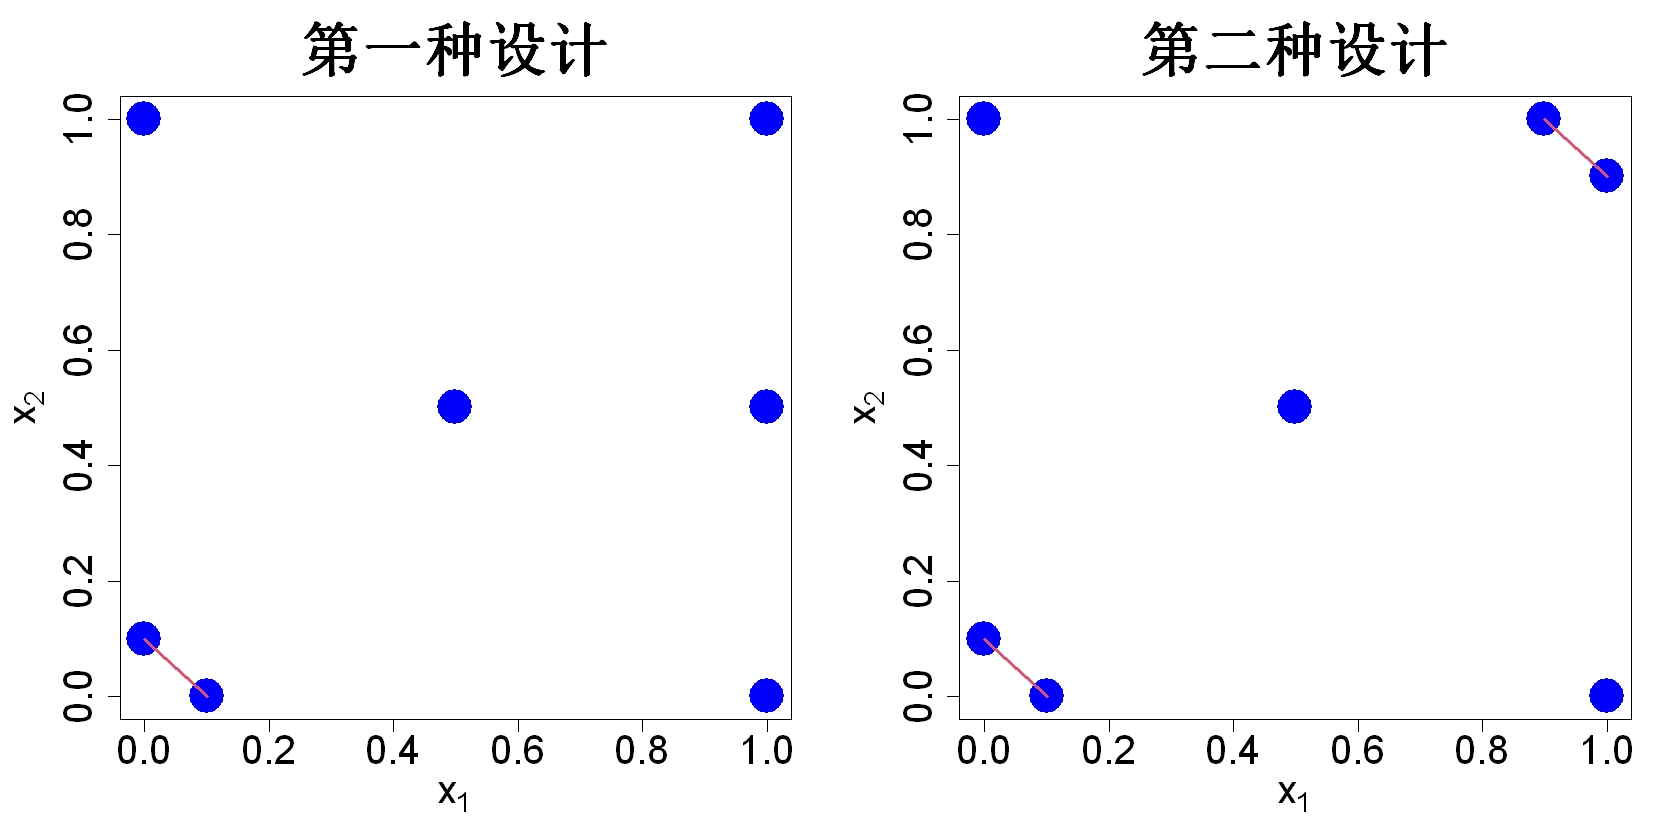

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.3-D.csv")){
  p=2;n=7
  D1=matrix(c(0,.1,.1,0,0,1,1,1,1,.5,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
  D2=matrix(c(0,.1,.1,0,0,1,.9,1,1,.9,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
  m.D=cbind(D1,D2)
  colnames(m.D)=c(paste0("D1.",1:2),paste0("D2.",1:2))
  write.csv(m.D,file="data/4.3-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.3-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(D1,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第一种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
plot(D2,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第二种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
segments(.9,1,1,.9,col=2,lwd=3)
par(mfrow=c(1,1))

> **图 4.4** 包含 7 个样本点的极大极小设计。

r: 0.267948 


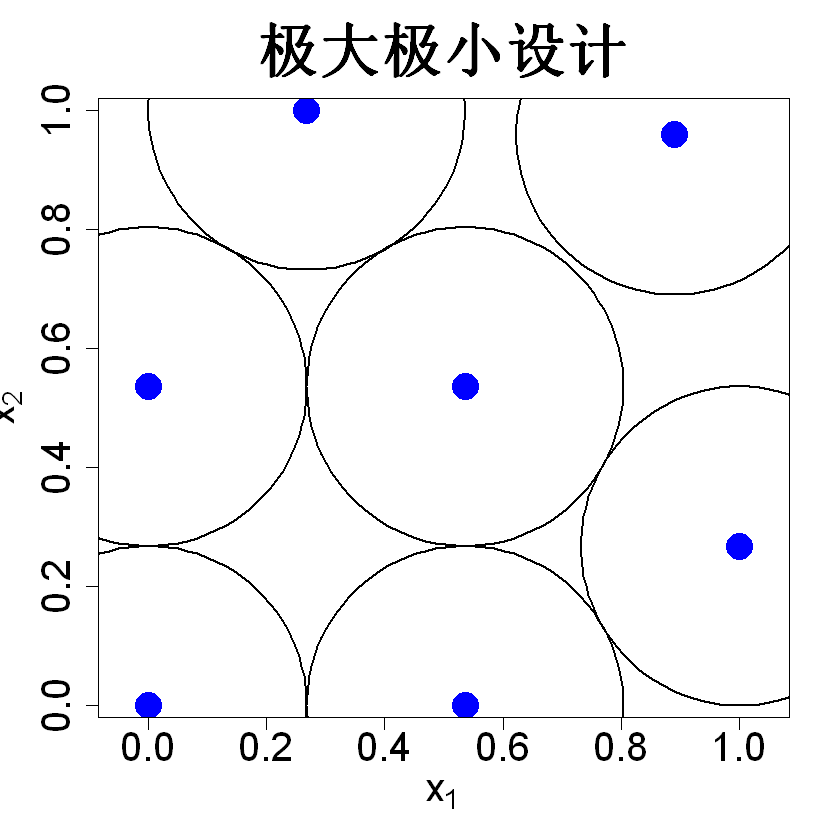

In [5]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.4-D.csv")||!file.exists("data/4.4-para.csv")){
  p=2;n=7
  set.seed(1)
  library(SFDesign)
  D=maximinLHD(n,p)$design
  D=maximin.optim(D,sa=TRUE,find.best.ini=TRUE)$design
  r=min(dist(D))/2
  m.D=cbind(D)
  colnames(m.D)=c(paste0("D.",1:2))
  write.csv(m.D,file="data/4.4-D.csv",row.names=FALSE)
  m.para=cbind(r=r,n=n)
  write.csv(m.para,file="data/4.4-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.4-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
para=read.csv("data/4.4-para.csv")
r=para$r;n=para$n

cat("r:",r,"\n")
options(repr.plot.width=7,repr.plot.height=7)
library(MASS)
eqscplot(D[,1],D[,2],xlab=expression(x[1]),ylab=expression(x[2]),xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2,main="极大极小设计")
library(plotrix)
for(i in 1:n) draw.circle(D[i,1],D[i,2],radius=r,lwd=2)

> **图 4.5** 左侧图像展示了以中心点为初始点、逐步构建而成的最大最小距离设计。右侧图像呈现依据最大最小准则，在该设计基础上新增六个点位（红色十字标记）扩充后的设计方案。

r1: 0.25 
r2: 0.1767767 


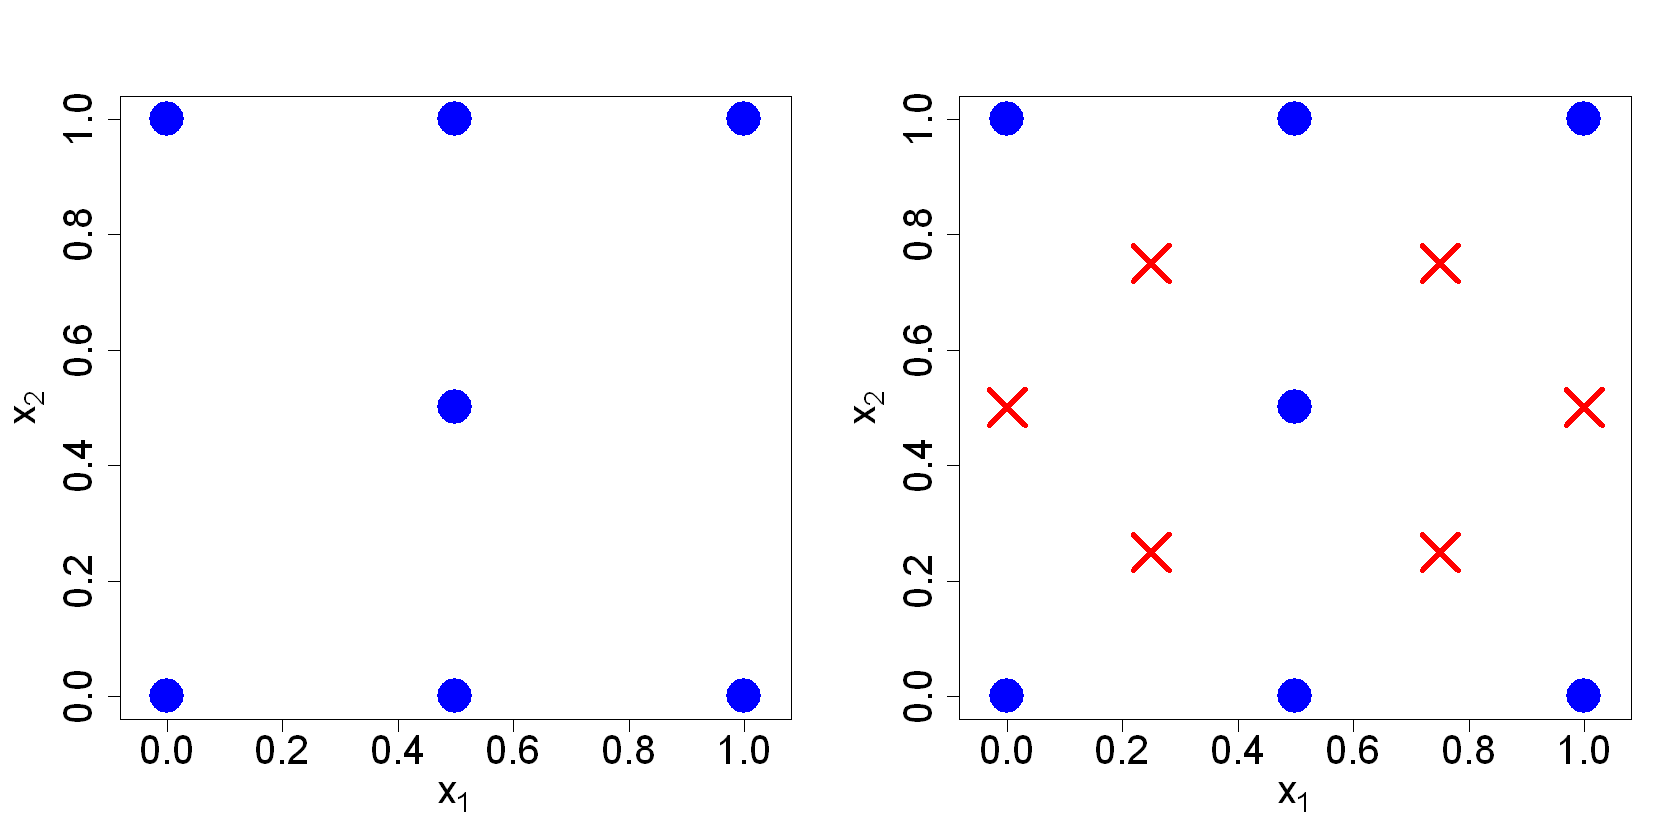

In [6]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.5-D1.csv")||!file.exists("data/4.5-D2.csv")){
  p=2;n=7
  set.seed(1)
  library(SFDesign)
  D0=matrix(c(.5,.5),nrow=1,ncol=p)
  CAND=full.factorial(p=2,level=5)
  D1=maximin.augment(n=7,p=2,D.ini=D0,candidate=CAND)
  min(dist(D1))/2
  D2=maximin.augment(n=13,p=2,D.ini=D1,candidate=CAND)
  min(dist(D2))/2
  D2_choose=D2[8:13,]
  m.D1=cbind(D1)
  colnames(m.D1)=c(paste0("D1.",1:2))
  write.csv(m.D1,file="data/4.5-D1.csv",row.names=FALSE)
  m.D2=cbind(D2_choose)
  colnames(m.D2)=c(paste0("D2.",1:2))
  write.csv(m.D2,file="data/4.5-D2.csv",row.names=FALSE)
}

df_D1=read.csv("data/4.5-D1.csv")
D1=as.matrix(df_D1[,paste0("D1.",1:2)])
df_D2=read.csv("data/4.5-D2.csv")
D2_choose=as.matrix(df_D2[,paste0("D2.",1:2)])

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
cat("r1:",min(dist(D1))/2,"\n")
plot(D1,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",asp=1)
plot(D1,xlim=c(0,1),ylim=c(0,1),cex=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",asp=1)
cat("r2:",min(dist(D2_choose))/2,"\n")
points(D2_choose,cex=4,lwd=5,pch=4,col="red")
par(mfrow=c(1,1))

> **图 4.6** 四轮试验下的极大极小与极小极大设计，及其在各坐标轴上的投影。

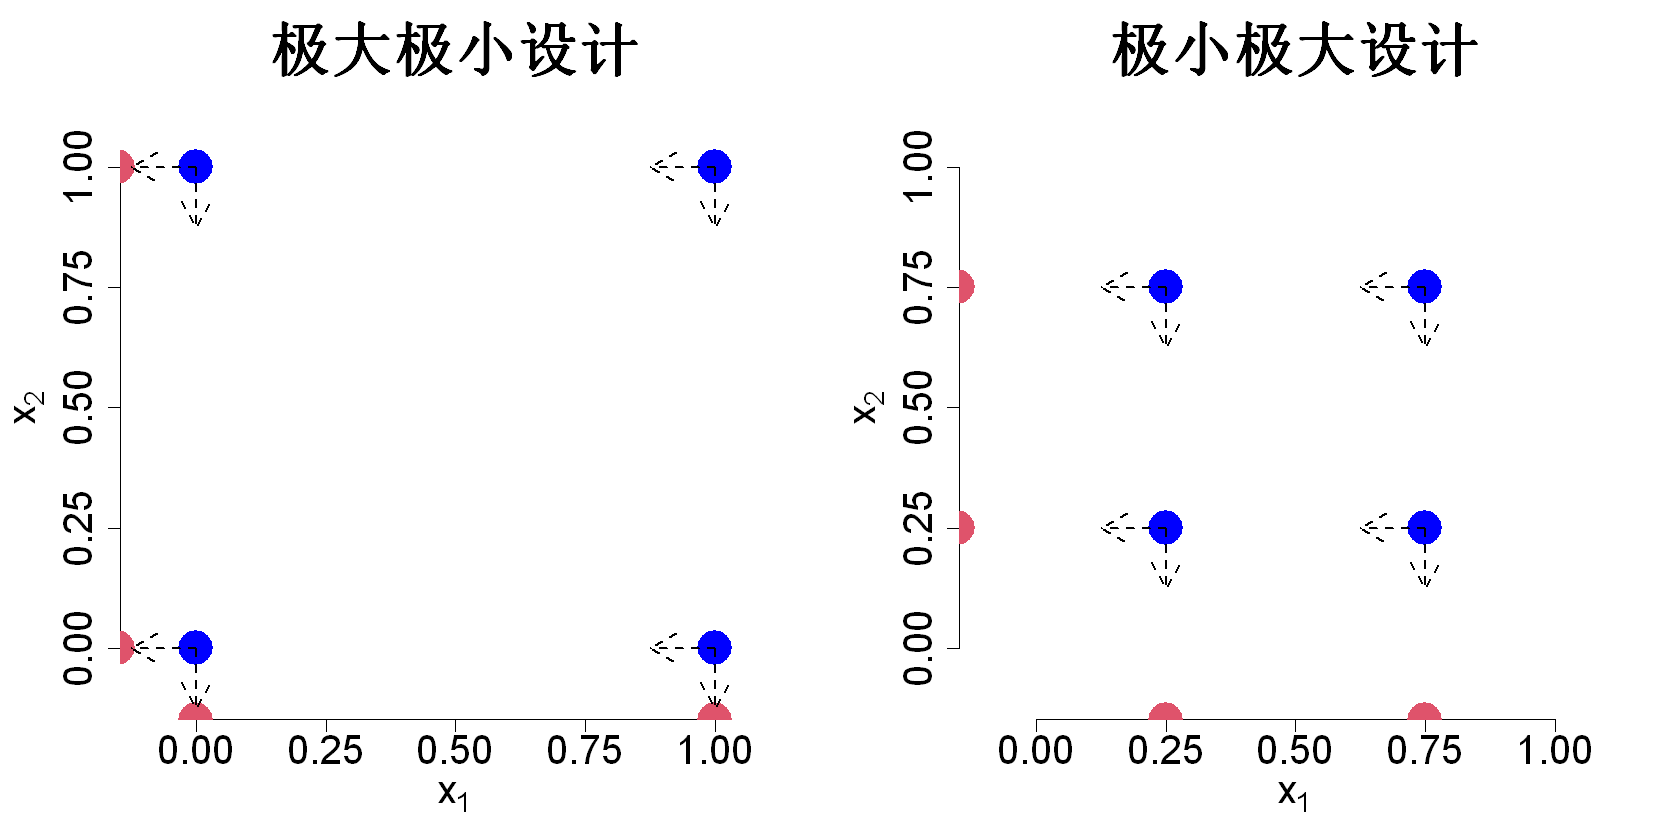

In [7]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.6-D.csv")){
  D1=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE) # 4x2
  D2=matrix(c(0.25,0.25,.25,.75,.75,.25,.75,.75),nrow=4,ncol=2,byrow=TRUE) # 4x2
  m.D=cbind(D1,D2)
  colnames(m.D)=c(paste0("D1.",1:2),paste0("D2.",1:2))
  write.csv(m.D,file="data/4.6-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.6-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(D1,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极大极小设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D1[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D1[,2]),col=2,pch=16,cex=4)
arrows(0,0,0,-.125,lwd=2,lty=2)
arrows(1,0,1,-.125,lwd=2,lty=2)
arrows(0,1,0,.875,lwd=2,lty=2)
arrows(1,1,1,.875,lwd=2,lty=2)
arrows(0,0,-.125,0,lwd=2,lty=2)
arrows(0,1,-.125,1,lwd=2,lty=2)
arrows(1,0,.875,0,lwd=2,lty=2)
arrows(1,1,.875,1,lwd=2,lty=2)
plot(D2,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极小极大设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D2[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D2[,2]),col=2,pch=16,cex=4)
arrows(.25,.25,.25,.125,lwd=2,lty=2)
arrows(.75,.25,.75,.125,lwd=2,lty=2)
arrows(.25,.75,.25,.625,lwd=2,lty=2)
arrows(.75,.75,.75,.625,lwd=2,lty=2)
arrows(.25,.25,.125,.25,lwd=2,lty=2)
arrows(.25,.75,.125,.75,lwd=2,lty=2)
arrows(.75,.25,.625,.25,lwd=2,lty=2)
arrows(.75,.75,.625,.75,lwd=2,lty=2)
par(mfrow=c(1,1))

> **图 4.7** 4 次采样的拉丁超立方设计，其投影分别展示在各坐标轴上。

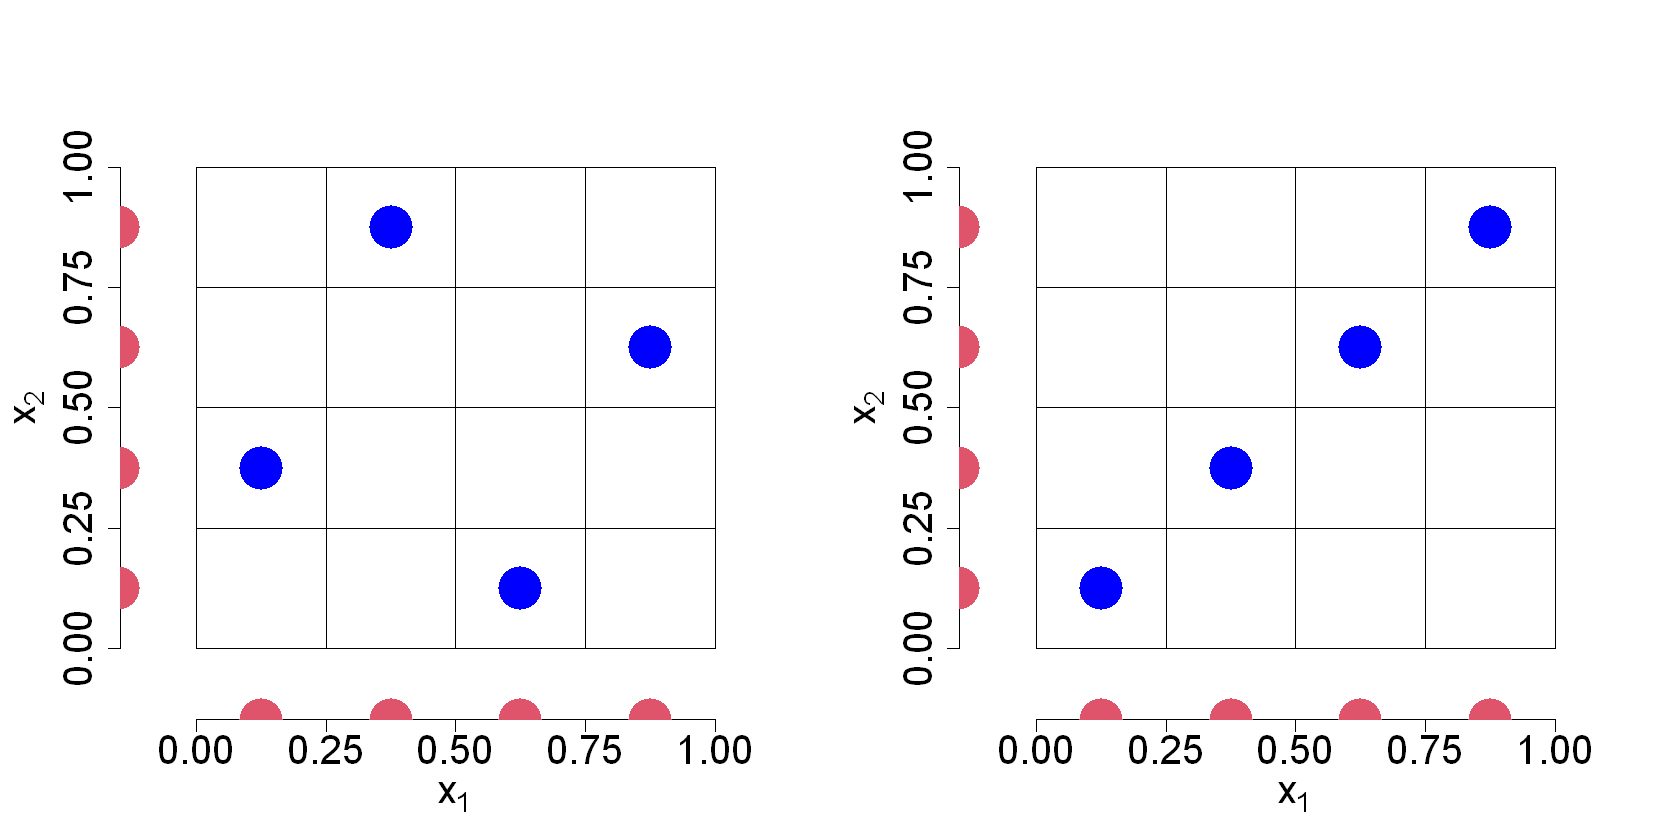

In [8]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.7-D.csv")||!file.exists("data/4.7-para.csv")){
  p=2;n=4
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 4x2
  D2=(cbind(1:n,1:n)-.5)/n # 4x2
  m.D=cbind(D1,D2)
  colnames(m.D)=c(paste0("D1.",1:2),paste0("D2.",1:2))
  write.csv(m.D,file="data/4.7-D.csv",row.names=FALSE)
  m.para=cbind(n=n)
  write.csv(m.para,file="data/4.7-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.7-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.7-para.csv")
n=para$n

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(D1,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D1[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D1[,2]),col=2,pch=16,cex=5)
plot(D2,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D2[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D2[,2]),col=2,pch=16,cex=5)
par(mfrow=c(1,1))

> **图 4.8** 7 点最大最小距离拉丁超立方设计。

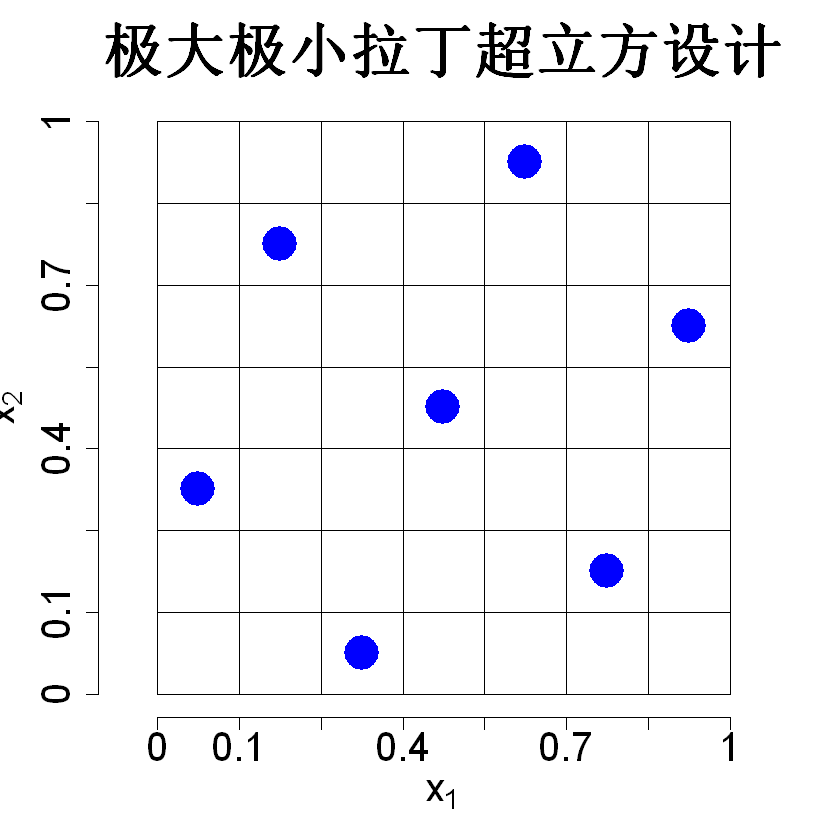

In [9]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.8-D.csv")||!file.exists("data/4.8-para.csv")){
  p=2;n=7
  library(SFDesign)
  D=maximinLHD(n,p)$design
  m.D=cbind(D)
  colnames(m.D)=c(paste0("D.",1:2))
  write.csv(m.D,file="data/4.8-D.csv",row.names=FALSE)
  m.para=cbind(n=n)
  write.csv(m.para,file="data/4.8-para.csv",row.names=FALSE)
}
df_D=read.csv("data/4.8-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
para=read.csv("data/4.8-para.csv")
n=para$n

options(repr.plot.width=7,repr.plot.height=7)
plot(D,pch=16,cex=4,axes=FALSE,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="极大极小拉丁超立方设计",cex.main=3,asp=1)
axis(1,at=seq(0,1,by=1/7),labels=round(seq(0,1,by=1/7),1),cex.axis=2)
axis(2,at=seq(0,1,by=1/7),labels=round(seq(0,1,by=1/7),1),cex.axis=2)
for(i in 1:(n+1)){
segments(0,(i-1)/n,1,(i-1)/n)
segments((i-1)/n,0,(i-1)/n,1)
}

> **图 4.9** 左侧图像展示了经过 20 次运算的最大最小拉丁超立方抽样（MmLHD），右侧图像则是该最大最小拉丁超立方抽样经切比雪夫变换后的结果。

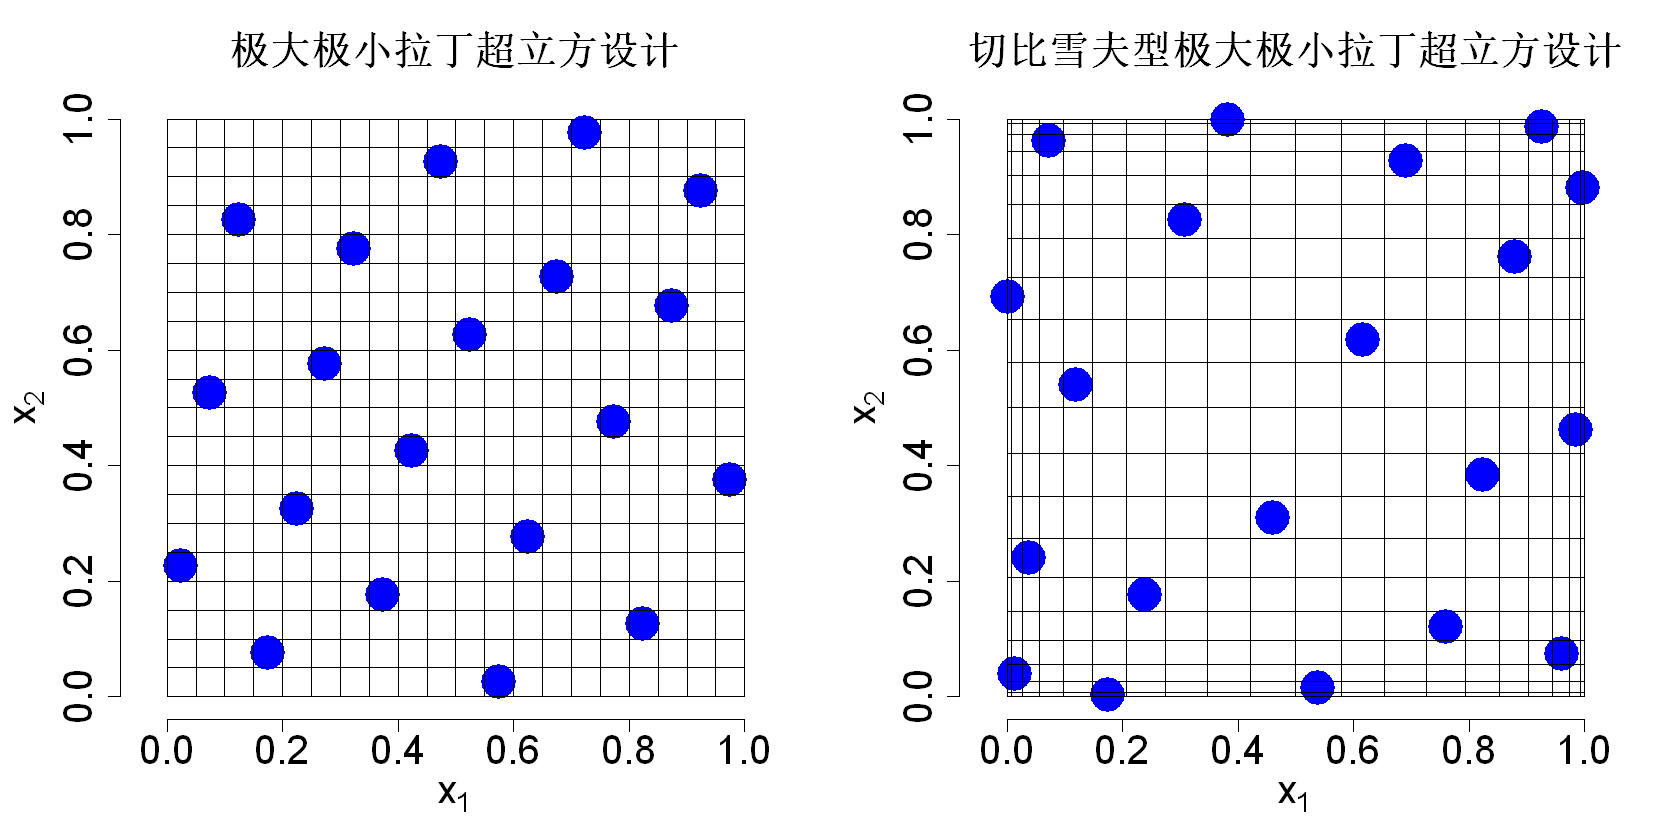

In [10]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.9-D.csv")||!file.exists("data/4.9-para.csv")){
  p=2;n=20
  set.seed(1)
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 20x2
  D2=(1+cos(pi*D1))/2 # 20x2
  m.D=cbind(D1,D2)
  colnames(m.D)=c(paste0("D1.",1:2),paste0("D2.",1:2))
  write.csv(m.D,file="data/4.9-D.csv",row.names=FALSE)
  m.para=cbind(n=n)
  write.csv(m.para,file="data/4.9-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.9-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.9-para.csv")
n=para$n

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="极大极小拉丁超立方设计",cex.lab=2,cex.axis=2,cex.main=2,asp=1)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
plot(D2,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="切比雪夫型极大极小拉丁超立方设计",cex.main=2,asp=1)
d1=sort(D2[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D2[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1)){
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))

> **图 4.10**：维度 $p=2$、样本量 $n=7$（左图）与 $n=20$（右图）对应的最大投影（MaxPro）设计。

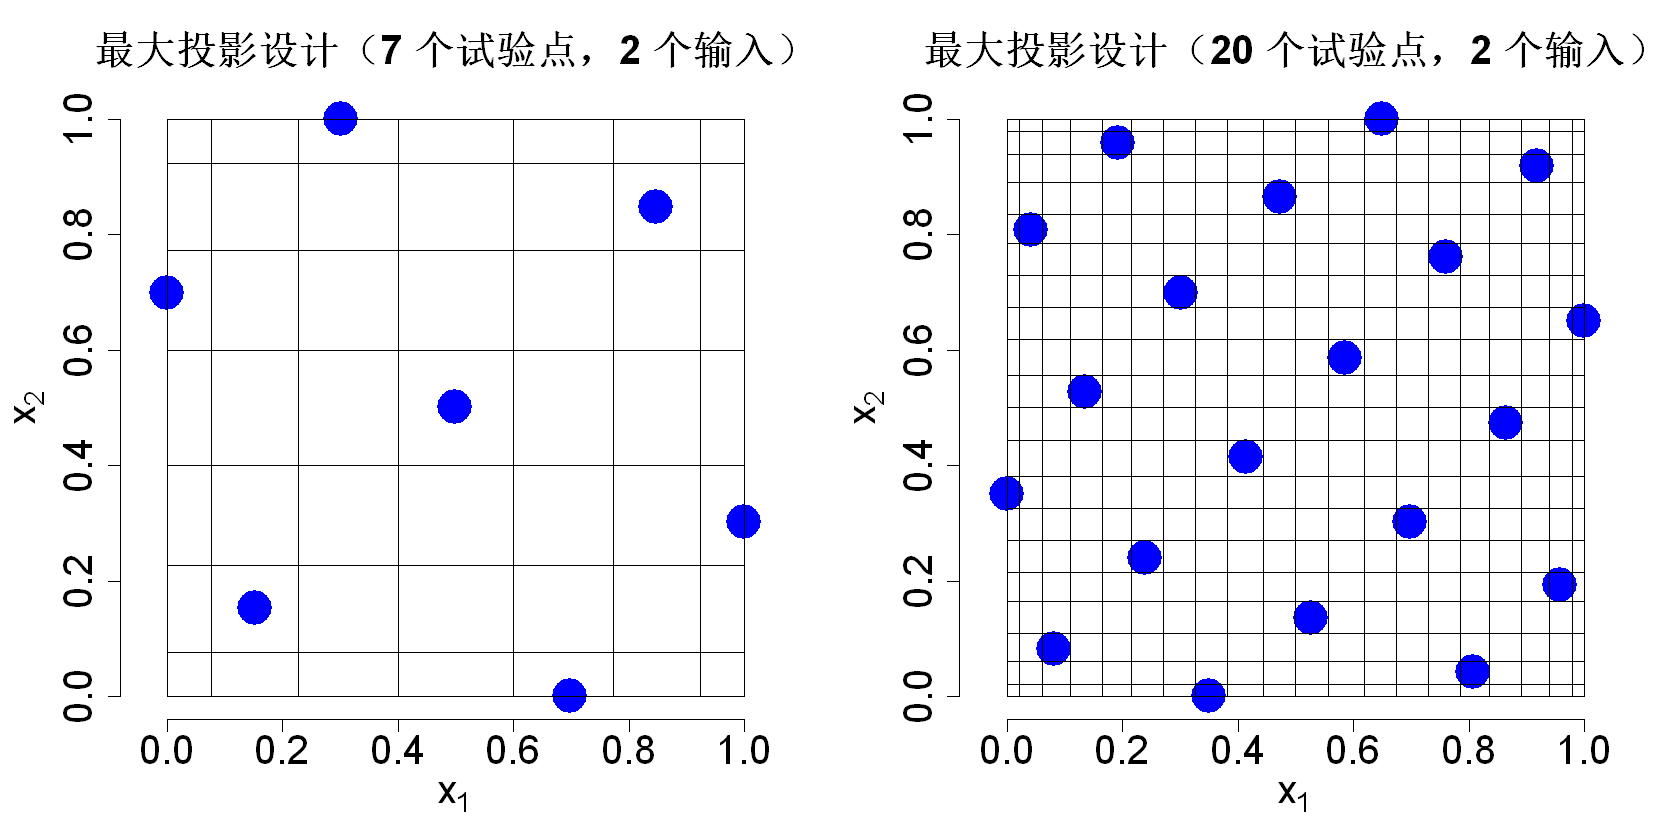

In [11]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.10-D1.csv")||!file.exists("data/4.10-D2.csv")||!file.exists("data/4.10-para.csv")){
  p=2;n=7
  library(MaxPro)
  a=MaxPro(MaxProLHD(n,p)$Design)
  D1=a$Design # 7x2
  p=2;n=20
  library(SFDesign)
  set.seed(10)
  D2=maxpro.optim(maxproLHD(n,p)$design,iteration=100)$design # 20x2
  maxpro.crit(D2)
  m.D1=cbind(D1)
  colnames(m.D1)=c(paste0("D1.",1:2))
  write.csv(m.D1,file="data/4.10-D1.csv",row.names=FALSE)
  m.D2=cbind(D2)
  colnames(m.D2)=c(paste0("D2.",1:2))
  write.csv(m.D2,file="data/4.10-D2.csv",row.names=FALSE)
  m.para=cbind(n1=7,n2=20)
  write.csv(m.para,file="data/4.10-para.csv",row.names=FALSE)
}

df_D1=read.csv("data/4.10-D1.csv")
D1=as.matrix(df_D1[,paste0("D1.",1:2)])
df_D2=read.csv("data/4.10-D2.csv")
D2=as.matrix(df_D2[,paste0("D2.",1:2)])
para=read.csv("data/4.10-para.csv")
n1=para$n1;n2=para$n2

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（7 个试验点，2 个输入）",cex.main=2,asp=1)
d11=sort(D1[,1])
l11=c(0,(d11[-1]+d11[-n1])/2,1)
d12=sort(D1[,2])
l12=c(0,(d12[-1]+d12[-n1])/2,1)
for(i in 1:(n1+1)){
segments(l11[i],0,l11[i],1)
segments(0,l12[i],1,l12[i])
}
plot(D2,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="最大投影设计（20 个试验点，2 个输入）",cex.main=2,asp=1)
d21=sort(D2[,1])
l21=c(0,(d21[-1]+d21[-n2])/2,1)
d22=sort(D2[,2])
l22=c(0,(d22[-1]+d22[-n2])/2,1)
for(i in 1:(n2+1)){
segments(l21[i],0,l21[i],1)
segments(0,l22[i],1,l22[i])
}
par(mfrow=c(1,1))

> **图 4.11** 样本量 $n=50$、维度 $p=5$ 的最大投影设计点散点矩阵图。

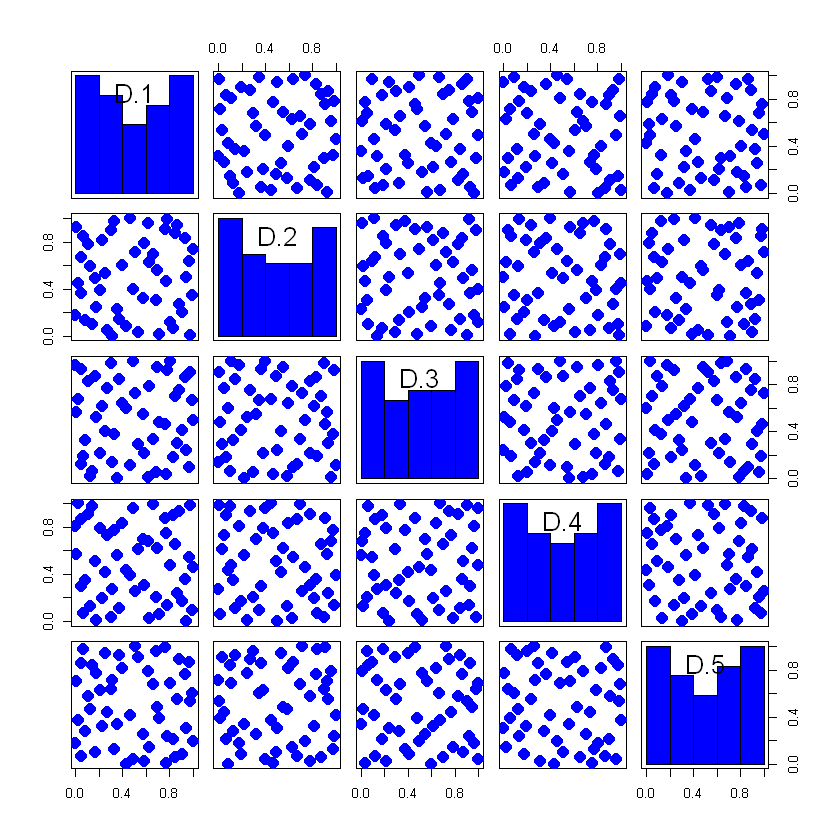

In [13]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.11-D.csv")){
  p=5;n=50
  set.seed(2)
  library(SFDesign)
  D=maxpro.optim(maxproLHD(n,p)$design)$design # 50x5
  maxpro.crit(D)
  m.D=cbind(D)
  colnames(m.D)=c(paste0("D.",1:p))
  write.csv(m.D,file="data/4.11-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.11-D.csv")
D=as.matrix(df_D[,paste0("D.",1:5)])

options(repr.plot.width=7,repr.plot.height=7)
library(car)
scatterplotMatrix(D,diagonal=list(method="histogram"),cex=2,smooth=FALSE,regLine=FALSE,pch=16)

> **图 4.12** 投影至子空间的各点之间最小距离的最小值。

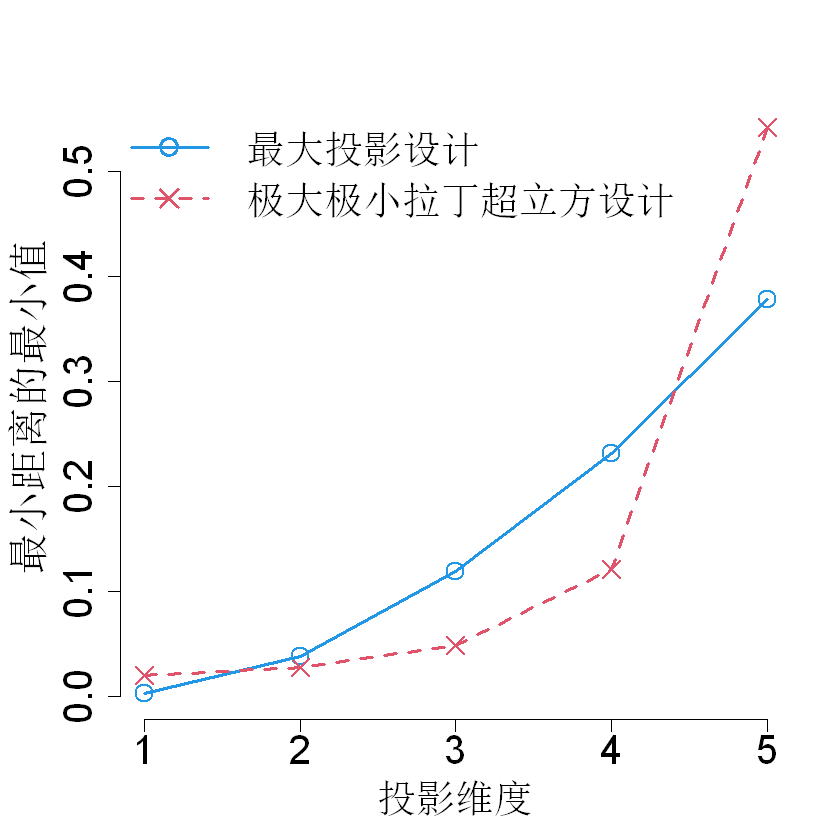

In [14]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.12-D.csv")||!file.exists("data/4.12-para.csv")){
  p=5;n=50
  set.seed(2)
  library(SFDesign)
  D=maxpro.optim(maxproLHD(n,p)$design)$design # MaxPro设计（对应图4.11的D）
  D0=maximinLHD(n,p)$design # MmLHD
  library(gtools)
  min_mindist=function(M)
  {
    n=dim(M)[1]
    p=dim(M)[2]
    a=rep(p,(p-1))
    for(j in 1:(p-1))
    {
      comb=combinations(p,j)
      k=dim(comb)[1]
      temp=mat.or.vec(k,1)
      for(i in 1:k){
        temp[i]=min(dist(M[,comb[i,]]))
      }
      a[j]=min(temp)
    }
    minfull=min(dist(M))
    return(c(a,minfull))
  }
  d1=min_mindist(D)
  d2=min_mindist(D0)
  m.D=cbind(d1=d1,d2=d2)
  write.csv(m.D,file="data/4.12-D.csv",row.names=FALSE)
  m.para=cbind(p=p)
  write.csv(m.para,file="data/4.12-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.12-D.csv")
d1=df_D$d1;d2=df_D$d2
para=read.csv("data/4.12-para.csv")
p=para$p

options(repr.plot.width=7,repr.plot.height=7)
par(mar=c(5,5,4,2))
matplot(1:p,cbind(d1,d2),type="pp",pch=c(1,4),col=c(4,2),ylim=c(0,.55),bty="n",axes=FALSE,xlab="投影维度",ylab="最小距离的最小值",cex=2,cex.lab=2,lwd=2)
axis(1,1:p,cex.axis=2)
axis(2,seq(0,.52,.1),cex.axis=2)
lines(d1,lwd=3,col=4)
lines(d2,lwd=3,lty=2,col=2)
legend("topleft",c("最大投影设计","极大极小拉丁超立方设计"),pch=c(1,4),lty=c(1,2),bty='n',lwd=3,col=c(4,2),cex=2)

> **图 4.13**：两组直方图分别展示 (64,6) 极大极小设计与 (64,6) 最大投影设计样本两两间距的分布；贝分布密度函数定义域缩放至 $[0,\sqrt6]$ 区间。

shape1: 10.0895 
shape2: 12.72548 


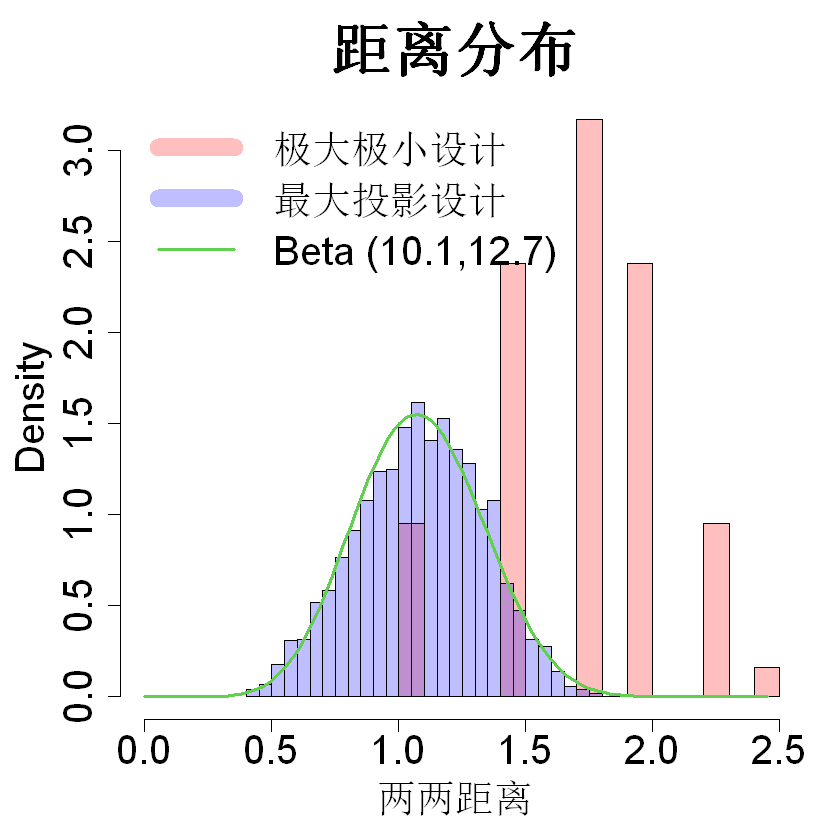

In [15]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.13-D.csv")||!file.exists("data/4.13-para.csv")){
  p=6;n=64
  set.seed(1)
  library(SFDesign)
  D0=maximin.optim(maximinLHD(n,p)$design,find.best.ini=TRUE)$design
  D1=maxpro.optim(maxproLHD(n,p)$design)$design
  d0=c(dist(D0)) # 2016x1
  d1=c(dist(D1)) # 2016x1
  library(fitdistrplus)
  a=fitdist(d1/sqrt(p),"beta")
  a$estimate
  m.D=cbind(d0=d0,d1=d1)
  write.csv(m.D,file="data/4.13-D.csv",row.names=FALSE)
  m.para=cbind(shape1=a$estimate[1],shape2=a$estimate[2],p=p)
  write.csv(m.para,file="data/4.13-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.13-D.csv")
d0=df_D$d0;d1=df_D$d1
para=read.csv("data/4.13-para.csv")
shape1=para$shape1;shape2=para$shape2;p=para$p

cat("shape1:",shape1,"\n")
cat("shape2:",shape2,"\n")

options(repr.plot.width=7,repr.plot.height=7)
par(mar=c(5,5,4,2))
hist(d0,prob=TRUE,xlim=c(0,sqrt(p)),col=rgb(1,0,0,1/4),xlab="两两距离",main="距离分布",cex.lab=2,cex.axis=2,cex.main=3)
hist(d1,prob=TRUE,col=rgb(0,0,1,1/4),breaks=30,add=TRUE)
curve(dbeta(x/sqrt(p),shape1,shape2)/sqrt(p),from=0,to=sqrt(p),add=TRUE,col=3,lwd=3)
legend("topleft",legend=c("极大极小设计","最大投影设计",paste0("Beta (",round(shape1,1),",",round(shape2,1),")")),col=c(rgb(1,0,0,1/4),rgb(0,0,1,1/4),3),lty=c(1,1,1),bty="n",lwd=c(15,15,3),cex=2)

> **图 4.14** 左侧图像展示了马克斯普罗设计样本（蓝色圆点）与通过序贯马克斯普罗方法生成的验证点（红色三角形）叠加在布拉宁函数图像上的效果。右侧图像为 100 组随机验证集均方根误差的箱线图。

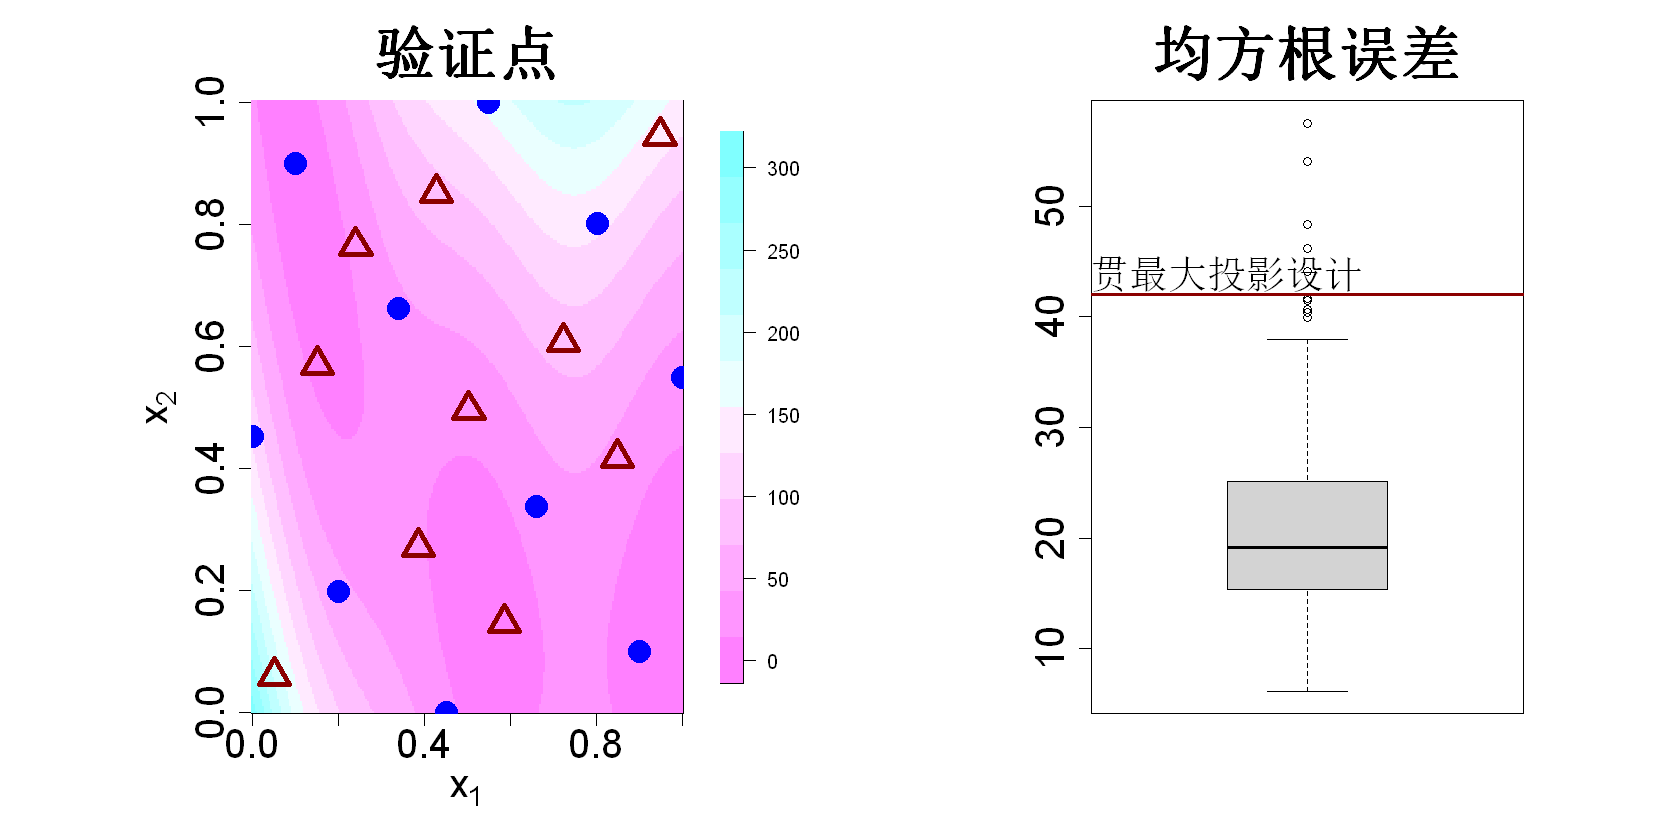

In [17]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.14-fc.csv")||!file.exists("data/4.14-p.csv")||!file.exists("data/4.14-rmse.csv")||!file.exists("data/4.14-para.csv")||!file.exists("data/4.14-D.csv")){
  branin=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    val1=(x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2
    val2=10*(1-1/(8*pi))*cos(x1)+10
    return(val1+val2)
  }
  p=2;n=10
  set.seed(123)
  library(MaxPro)
  D=MaxPro(MaxProLHD(n,p)$Design)$Design # 10x2
  CAND=CandPoints(N=10000,2)
  A=MaxProAugment(ExistDesign=D,CandDesign=CAND,nNew=10)$Design[(n+1):20,] # 10x2
  y=apply(D,1,branin)
  library(rkriging)
  a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
  true=apply(A,1,branin)
  pred=Predict.Kriging(a,A)$mean
  rmse0=sqrt(mean((pred-true)^2))
  rmse=numeric(100)
  for(i in 1:100){
    u=matrix(runif(p*10),nrow=10,ncol=p)
    pred=Predict.Kriging(a,u)$mean
    true=apply(u,1,branin)
    rmse[i]=sqrt(mean((pred-true)^2))
  }
  N.plot=250
  p1=seq(0,1,length=N.plot)
  p2=seq(0,1,length=N.plot)
  fc=matrix(0,N.plot,N.plot)
  for(i in 1:N.plot){
    for(j in 1:N.plot)
      fc[i,j]=branin(c(p1[i],p2[j]))
  }
  m.D=cbind(D,A)
  colnames(m.D)=c(paste0("D.",1:2),paste0("A.",1:2))
  write.csv(m.D,file="data/4.14-D.csv",row.names=FALSE)
  m.fc=cbind(fc)
  colnames(m.fc)=c(paste0("fc.",1:N.plot))
  write.csv(m.fc,file="data/4.14-fc.csv",row.names=FALSE)
  m.p=cbind(p1=p1,p2=p2)
  write.csv(m.p,file="data/4.14-p.csv",row.names=FALSE)
  m.rmse=cbind(rmse=rmse)
  write.csv(m.rmse,file="data/4.14-rmse.csv",row.names=FALSE)
  m.para=cbind(rmse0=rmse0)
  write.csv(m.para,file="data/4.14-para.csv",row.names=FALSE)
}

df_fc=read.csv("data/4.14-fc.csv")
fc=as.matrix(df_fc)
df_p=read.csv("data/4.14-p.csv")
p1=df_p$p1;p2=df_p$p2
rmse=read.csv("data/4.14-rmse.csv")$rmse
df_D=read.csv("data/4.14-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
A=as.matrix(df_D[,paste0("A.",1:2)])
rmse0=read.csv("data/4.14-para.csv")$rmse0

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
library(fields)
imagePlot(p1,p2,fc,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(12,rev=TRUE),main="验证点",cex.main=3,cex.lab=2,cex.axis=2)
points(D,pch=16,col="blue",lwd=4,cex=2.5)
points(A,pch=2,col="darkred",lwd=4,cex=2.5)
boxplot(rmse,main="均方根误差",cex.main=3,cex.axis=2)
abline(h=rmse0,col="darkred",lwd=3)
text(.75,rmse0+2,"序贯最大投影设计",cex=2)
par(mfrow=c(1,1))

> **图 4.15**：式 (4.30) 中约束条件对应的可行域以阴影区域展示。

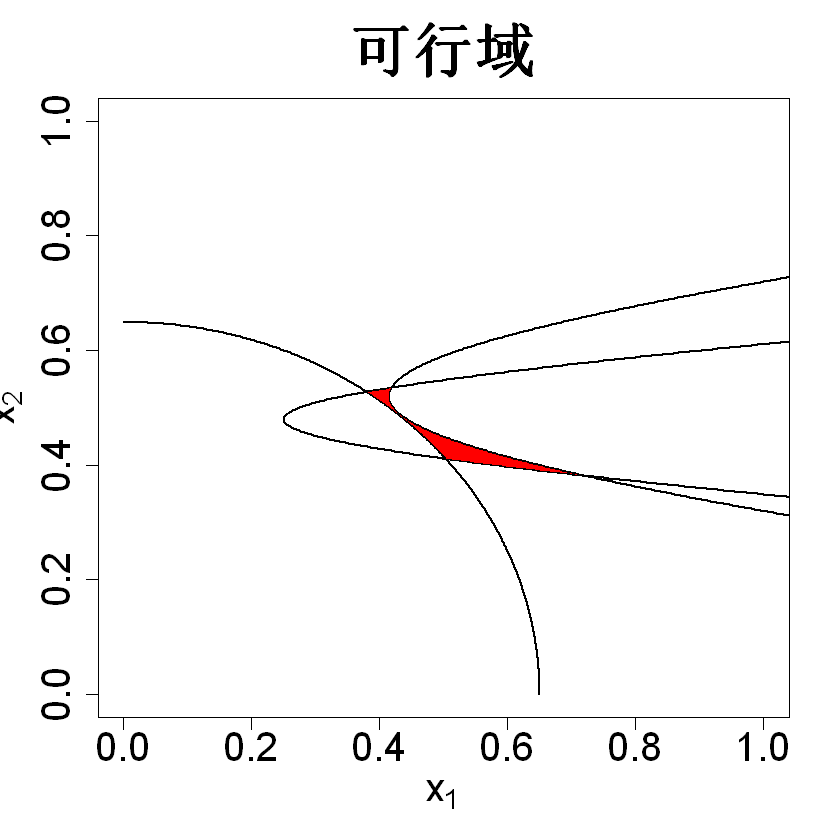

In [18]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.15-x.csv")){
  constraint=function(x){
    c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
    c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
    c3=(0.65^2-x[1]^2-x[2]^2)
    return(c(c1,c2,c3))
  }
  x1=x2=matrix(NA,nrow=3,ncol=1001)
  x2.seq=seq(0,1,length.out=1001)
  x2[1,]=x2.seq
  x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
  x2[2,]=x2.seq
  x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
  x2[3,]=x2.seq
  x1[3,]=sqrt(0.65^2-x2.seq^2)
  contour=list(x1=x1,x2=x2)
  m.x=cbind(t(x1),t(x2))
  colnames(m.x)=c(paste0("x1.",1:3),paste0("x2.",1:3))
  write.csv(m.x,file="data/4.15-x.csv",row.names=FALSE)
}

df_x=read.csv("data/4.15-x.csv")
x1=t(as.matrix(df_x[,paste0("x1.",1:3)]))
x2=t(as.matrix(df_x[,paste0("x2.",1:3)]))

options(repr.plot.width=7,repr.plot.height=7)
plot(NULL,type="n",xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="可行域",cex.main=3)
for(i in 1:3) lines(x1[i,],x2[i,],lwd=2)
polygon(x=c(x1[1,383:536],x1[2,536:529],x1[3,529:412],x1[2,412:383]),
        y=c(x2[1,383:536],x2[2,536:529],x2[3,529:412],x2[2,412:383]),
        col="red")

> **图 4.16**：100000 个拉丁超立方采样点（左）、可行点（中）以及最大投影设计（右）。

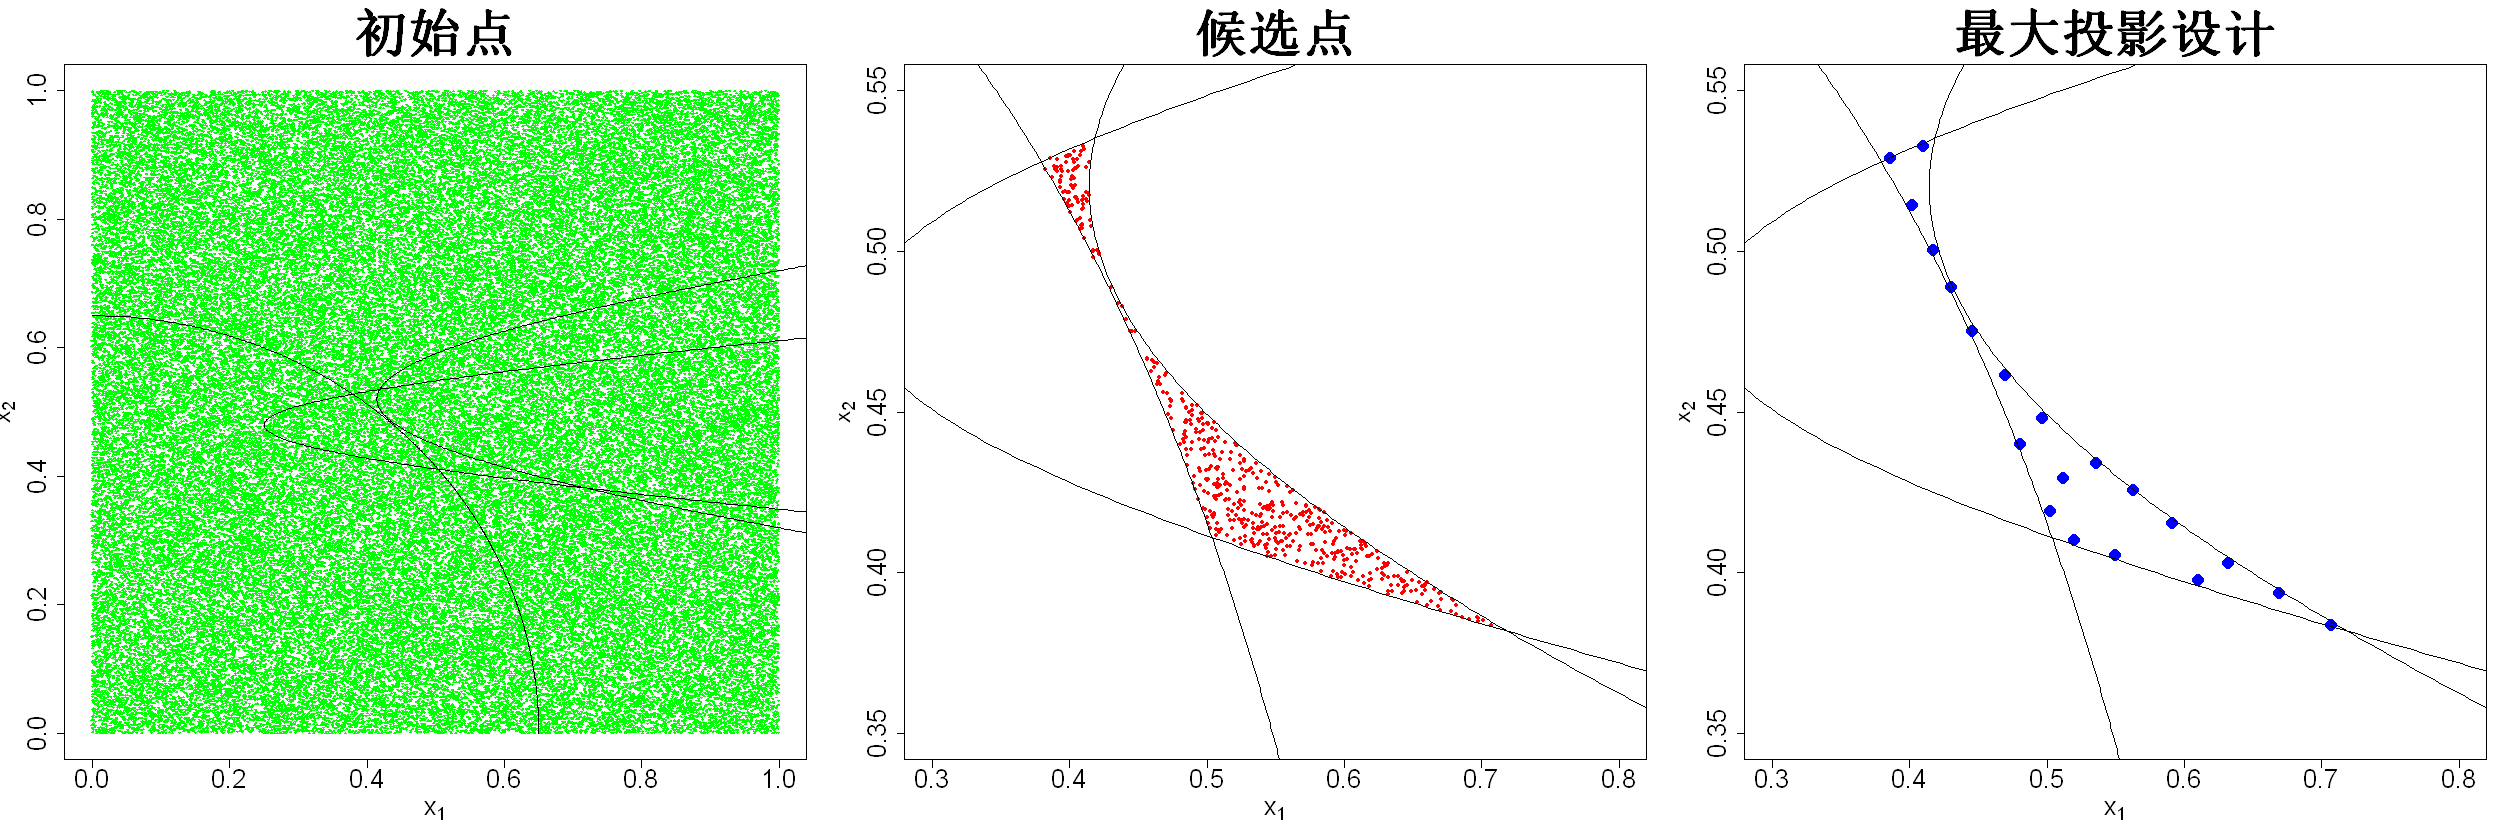

In [19]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.16-x.csv")||!file.exists("data/4.16-all.csv")||!file.exists("data/4.16-feasible.csv")||!file.exists("data/4.16-maxpro.csv")){
  constraint=function(x){
    c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
    c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
    c3=(0.65^2-x[1]^2-x[2]^2)
    return(c(c1,c2,c3))
  }
  x1=x2=matrix(NA,nrow=3,ncol=1001)
  x2.seq=seq(0,1,length.out=1001)
  x2[1,]=x2.seq
  x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
  x2[2,]=x2.seq
  x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
  x2[3,]=x2.seq
  x1[3,]=sqrt(0.65^2-x2.seq^2)
  N=1e5
  set.seed(1)
  library(lhs)
  lhs.all=randomLHS(N,2) # 1e5x2
  lhs.gval=t(apply(lhs.all,1,constraint)) # 1e5x3
  lhs.out.idx=apply(lhs.gval,1,function(x) return(any(x>0)))
  lhs.feasible=lhs.all[!lhs.out.idx,] # 538x2
  nrow(lhs.feasible)
  n=20
  library(MaxPro)
  a=MaxProAugment(ExistDesign=lhs.feasible[1,],CandDesign=lhs.feasible[-1,],nNew=n-1)
  D=a$Design # 20x2
  m.x=cbind(t(x1),t(x2))
  colnames(m.x)=c(paste0("x1.",1:3),paste0("x2.",1:3))
  write.csv(m.x,file="data/4.16-x.csv",row.names=FALSE)
  m.all=cbind(lhs.all)
  colnames(m.all)=c("all.1","all.2")
  write.csv(m.all,file="data/4.16-all.csv",row.names=FALSE)
  m.feasible=cbind(lhs.feasible)
  colnames(m.feasible)=c("feasible.1","feasible.2")
  write.csv(m.feasible,file="data/4.16-feasible.csv",row.names=FALSE)
  m.maxpro=cbind(D)
  colnames(m.maxpro)=c("maxpro.1","maxpro.2")
  write.csv(m.maxpro,file="data/4.16-maxpro.csv",row.names=FALSE)
}

df_x=read.csv("data/4.16-x.csv")
x1=t(as.matrix(df_x[,paste0("x1.",1:3)]))
x2=t(as.matrix(df_x[,paste0("x2.",1:3)]))
all=as.matrix(read.csv("data/4.16-all.csv"))
feasible=as.matrix(read.csv("data/4.16-feasible.csv"))
maxpro=as.matrix(read.csv("data/4.16-maxpro.csv"))

options(repr.plot.width=21,repr.plot.height=7)
layout(matrix(c(1:3),nrow=1,byrow=TRUE))
plot(all,col="green",pch=18,cex=.5,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="初始点",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3) lines(x1[i,],x2[i,])
plot(feasible,col="red",pch=16,cex=.75,xlim=c(.3,.8),ylim=c(.35,.55),xlab=expression(x[1]),ylab=expression(x[2]),main="候选点",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3) lines(x1[i,],x2[i,])
plot(maxpro,col="blue",pch=16,cex=2,xlim=c(.3,.8),ylim=c(.35,.55),xlab=expression(x[1]),ylab=expression(x[2]),main="最大投影设计",cex.lab=2,cex.main=4,cex.axis=2)
for(i in 1:3) lines(x1[i,],x2[i,])
layout(matrix(c(1:1),nrow=1,byrow=TRUE))

> **图 4.17**：包含两个定量因子（$x_1$、$x_2$）和一个三水平定性因子（$x_3$）的设计：随机拉丁超立方设计（左）、分片拉丁超立方设计（中）以及最大投影设计（右）。

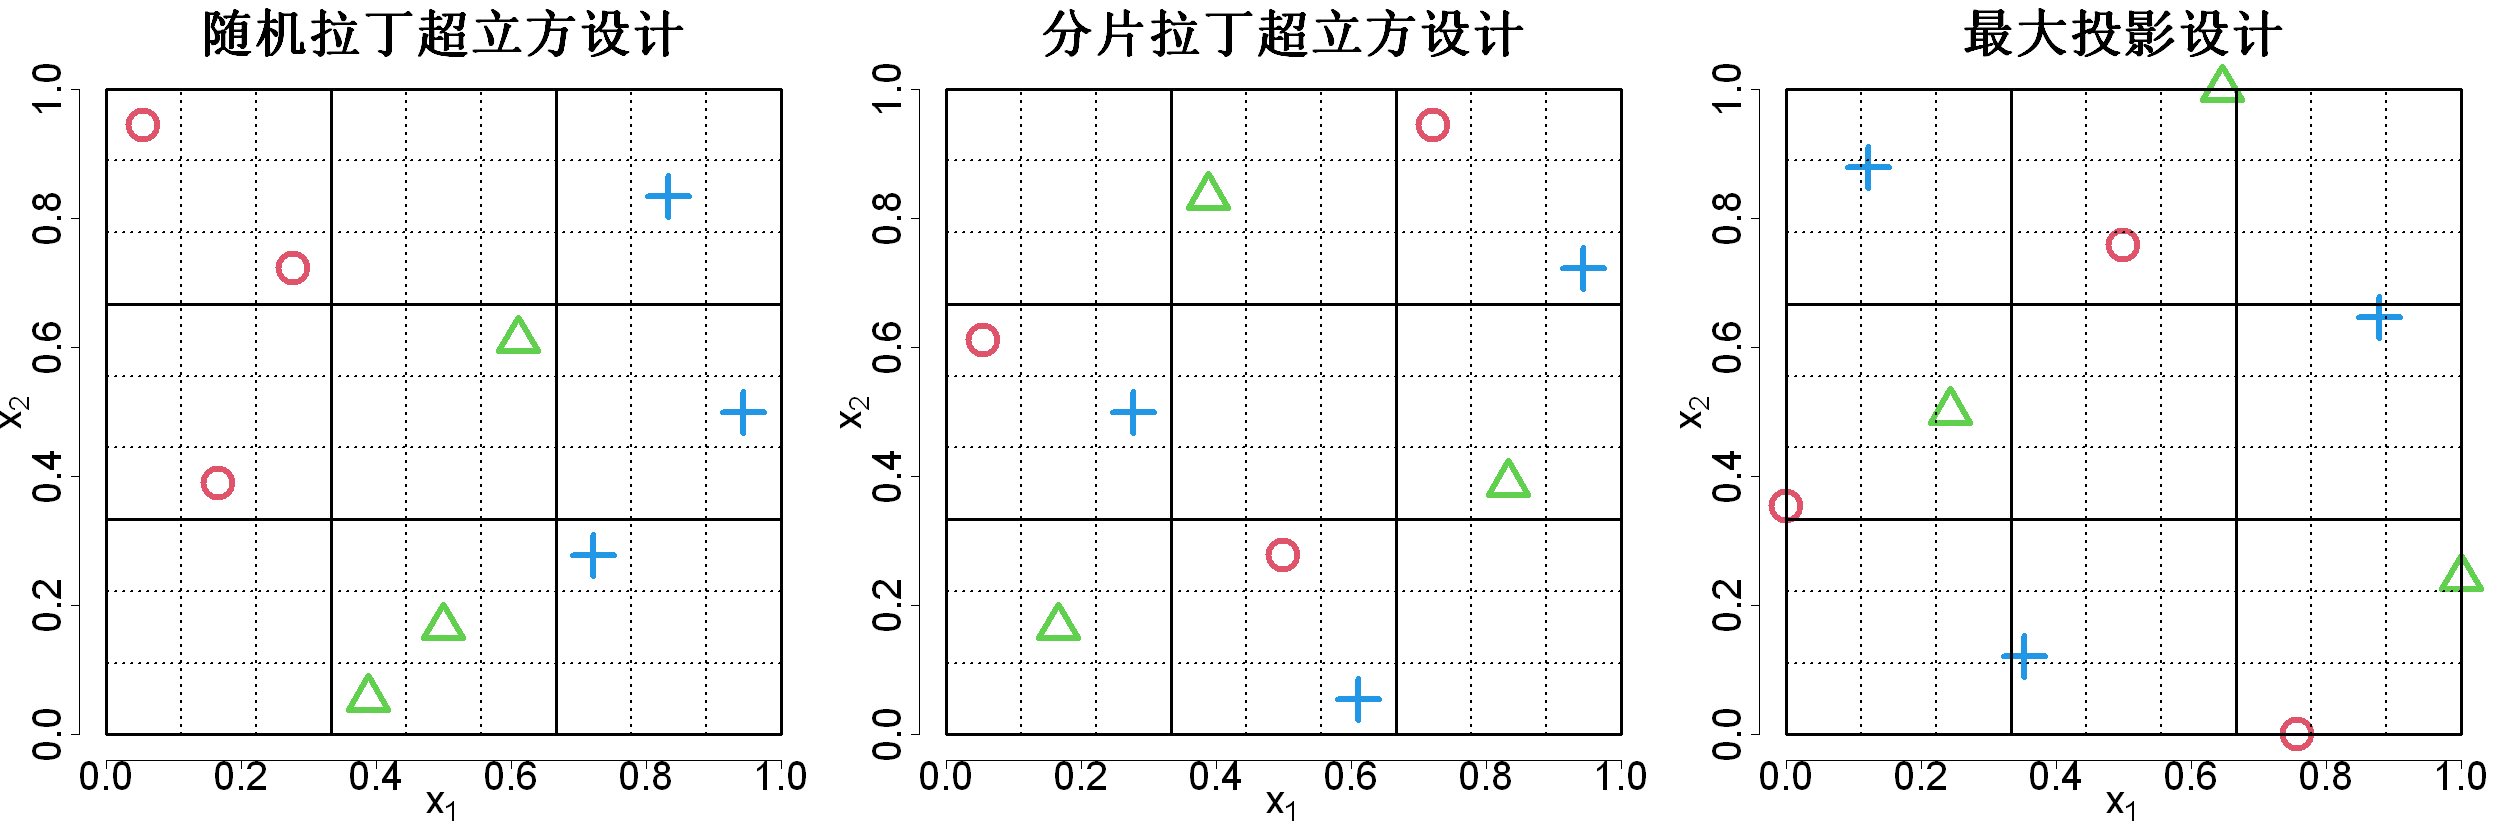

In [20]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.17-D.csv")||!file.exists("data/4.17-para.csv")){
  p=2;n=9
  set.seed(1)
  D0=cbind(rep(c(1,2,3),rep(3,3)),1:9,sample(1:9))
  D0[,2:3]=(D0[,2:3]-.5)/9
  library(SLHD)
  a=maximinSLHD(3,3,2)
  D1=a$StandDesign
  library(MaxPro)
  set.seed(3)
  ini=cbind(MaxPro(MaxProLHD(n,p)$Design)$Design,rep(1:3,c(3,3,3)))
  a=MaxProQQ(InitialDesign=ini,p_nom=1)
  a$measure
  D=a$Design
  m.D=cbind(D0,D1,D)
  colnames(m.D)=c(paste0("D0.",1:3),paste0("D1.",1:3),paste0("D.",1:3))
  write.csv(m.D,file="data/4.17-D.csv",row.names=FALSE)
  m.para=cbind(p=p,n=n)
  write.csv(m.para,file="data/4.17-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.17-D.csv")
D0=as.matrix(df_D[,paste0("D0.",1:3)])
D1=as.matrix(df_D[,paste0("D1.",1:3)])
D=as.matrix(df_D[,paste0("D.",1:3)])
para=read.csv("data/4.17-para.csv")
p=para$p;n=para$n

options(repr.plot.width=21,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,3))
plot(D0[,2:3],bty="n",pch=D0[,1],col=D0[,1]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="随机拉丁超立方设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3,xlim=c(0,1),ylim=c(0,1))
for(i in 1:n){
  segments(i/n,0,i/n,1,lty=3,lwd=2)
  segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
  segments(3*i/n,0,3*i/n,1,lwd=3)
  segments(0,3*i/n,1,3*i/n,lwd=3)
}
plot(D1[,2:3],bty="n",pch=D1[,1],col=D1[,1]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="分片拉丁超立方设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3,xlim=c(0,1),ylim=c(0,1))
for(i in 1:n){
  segments(i/n,0,i/n,1,lty=3,lwd=2)
  segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
  segments(3*i/n,0,3*i/n,1,lwd=3)
  segments(0,3*i/n,1,3*i/n,lwd=3)
}
plot(D[,1:2],bty="n",pch=D[,3],col=D[,3]+1,lwd=5,xlab=expression(x[1]),ylab=expression(x[2]),main="最大投影设计",cex=5,cex.lab=3,cex.main=4,cex.axis=3)
for(i in 0:n){
  segments(i/n,0,i/n,1,lty=3,lwd=2)
  segments(0,i/n,1,i/n,lty=3,lwd=2)
}
for(i in 0:(n/3)){
  segments(3*i/n,0,3*i/n,1,lwd=3)
  segments(0,3*i/n,1,3*i/n,lwd=3)
}
par(mfrow=c(1,1))

> **图 4.19**：硬车削实验 30 次分支设计的散点图矩阵。

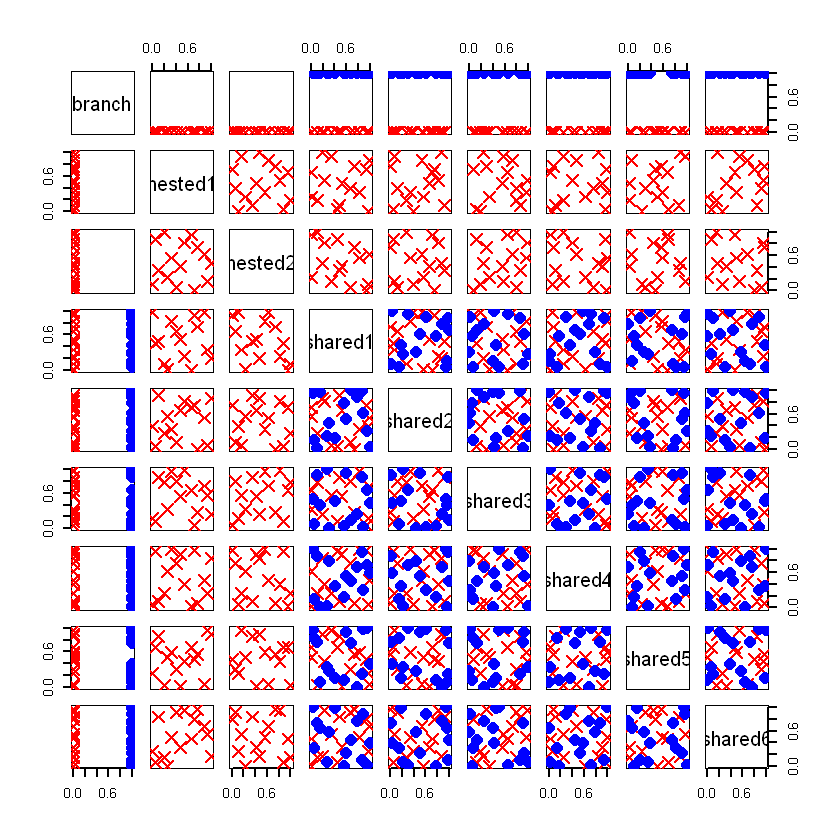

In [21]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.19-D.csv")){
  library(SFDesign)
  library(MaxPro)
  # 寻找最优初始设计（最优种子）
  for(k in 1:20){
    set.seed(k)
    shared_nested.ini=maxpro.optim(maxproLHD(30,6+2)$design)$design
    branch=rep(c(0,1),c(15,15))
    ini=cbind(shared_nested.ini,branch)
    D0=MaxProQQ(ini,p_nom=1)$Design
    na_nested=matrix(NA,nrow=15,ncol=2)
    val=matrix(Inf,nrow=8,ncol=8)
    D1=D0[1:15,-9]
    D2=D0[16:30,-9]
    for(i in 1:7){
      for(j in (i+1):8){
        B=D2
        B[,c(i,j)]=na_nested
        A=D1
        A[,c(i,j)]=(apply(D1[,c(i,j)],2,rank)-.5)/15
        A[,c(i,j)]=maxpro.optim(A[,c(i,j)])$design
        D=cbind(rbind(A,B),branch)
        val[i,j]=MaxProMeasure(D[,-c(i,j)])+MaxProMeasure(D[1:15,-9])+MaxProMeasure(D[16:30,-c(9,i,j)])
      }
    }
    print(c(k,min(val)))
  }
  opt.seed=12
  set.seed(opt.seed)
  shared_nested.ini=maxpro.optim(maxproLHD(30,6+2)$design)$design
  branch=rep(c(0,1),c(15,15))
  ini=cbind(shared_nested.ini,branch)
  D0=MaxProQQ(ini,p_nom=1)$Design
  na_nested=matrix(NA,nrow=15,ncol=2)
  val=matrix(Inf,nrow=8,ncol=8)
  D1=D0[1:15,-9]
  D2=D0[16:30,-9]
  for(i in 1:7){
    for(j in (i+1):8){
      B=D2
      B[,c(i,j)]=na_nested
      A=D1
      A[,c(i,j)]=(apply(D1[,c(i,j)],2,rank)-.5)/15
      A[,c(i,j)]=maxpro.optim(A[,c(i,j)])$design
      D=cbind(rbind(A,B),branch)
      val[i,j]=MaxProMeasure(D[1:15,-9])+MaxProMeasure(D[16:30,-c(9,i,j)])
    }
  }
  ind=c(which(val==min(val),arr.ind=TRUE))
  B=D2
  B[,ind]=na_nested
  A=D1
  A[,ind]=(apply(D1[,ind],2,rank)-.5)/15
  A[,ind]=maxpro.optim(A[,ind])$design
  D=cbind(rbind(A,B),branch)
  print(c(MaxProMeasure(D[,-ind]),MaxProMeasure(D[1:15,-9]),MaxProMeasure(D[16:30,-c(9,ind)])))
  temp=D
  temp[,1]=D[,9]
  temp[,2:3]=D[,ind]
  temp[,4:9]=D[,-c(9,ind)]
  D=temp
  colnames(D)=c("branch","nested1","nested2",paste("shared",sep="",1:6))
  m.D=cbind(D)
  write.csv(m.D,file="data/4.19-D.csv",row.names=FALSE)
}

D=as.matrix(read.csv("data/4.19-D.csv"))

options(repr.plot.width=7,repr.plot.height=7)
pairs(D,pch=ifelse(D[,"branch"]==0,4,16),col=ifelse(D[,"branch"]==0,"red","blue"),lwd=2,cex.labels=1.5,cex=2)

> **图 4.21**：包含两个保真度层级的多保真度模拟嵌套设计。$D_1$ 以蓝色圆点表示，$D_2$ 以红色三角形表示。

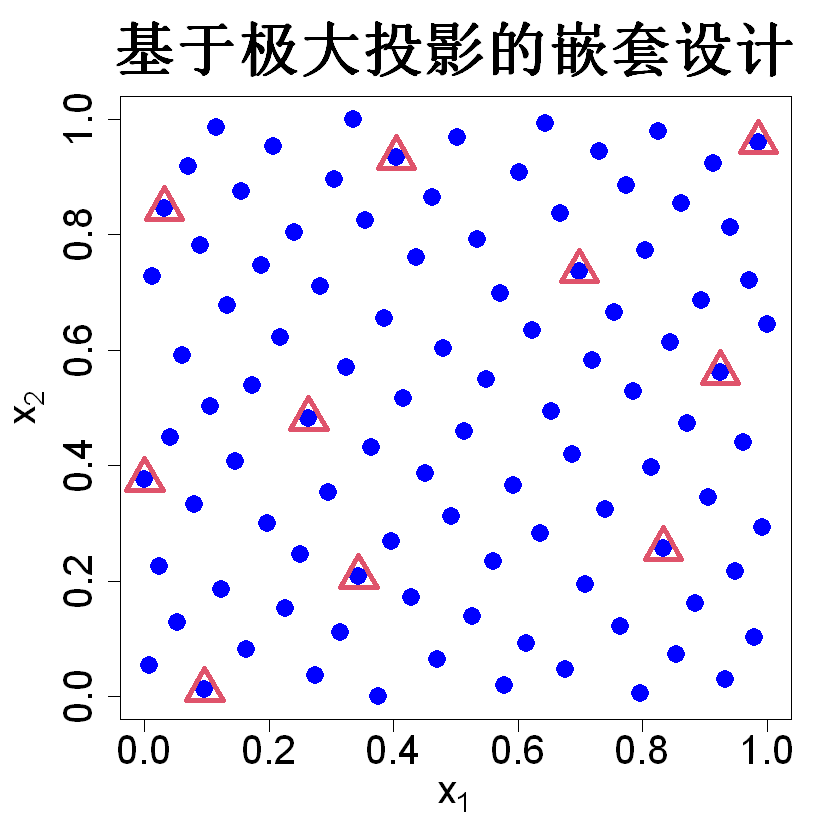

In [22]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.21-D1.csv")||!file.exists("data/4.21-D2.csv")){
  n1=100;n2=10;p=2
  set.seed(1)
  library(SFDesign)
  D1=maxpro.optim(maxproLHD(n1,p)$design)$design # 100x2
  maxpro.crit(D1)
  D2=maxpro.remove(D1,n.remove=n1-n2,delta=1/n1^2) # 10x2
  maxpro.crit(D2)
  m.D1=cbind(D1)
  colnames(m.D1)=c(paste0("D1.",1:2))
  write.csv(m.D1,file="data/4.21-D1.csv",row.names=FALSE)
  m.D2=cbind(D2)
  colnames(m.D2)=c(paste0("D2.",1:2))
  write.csv(m.D2,file="data/4.21-D2.csv",row.names=FALSE)
}

D1=as.matrix(read.csv("data/4.21-D1.csv"))
D2=as.matrix(read.csv("data/4.21-D2.csv"))

options(repr.plot.width=7,repr.plot.height=7)
par(mar=c(5,5,4,2))
plot(D1,xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",lwd=4,cex=2,main="基于极大投影的嵌套设计",xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,cex.main=3)
points(D2,pch=2,col=2,lwd=4,cex=3)

> **图 4.22**：极大极小设计与最小能量设计以蓝色圆点展示。2020 年人口普查得到的美国各地邮政编码点位以粉色圆点展示，圆点大小与人口密度成正比。

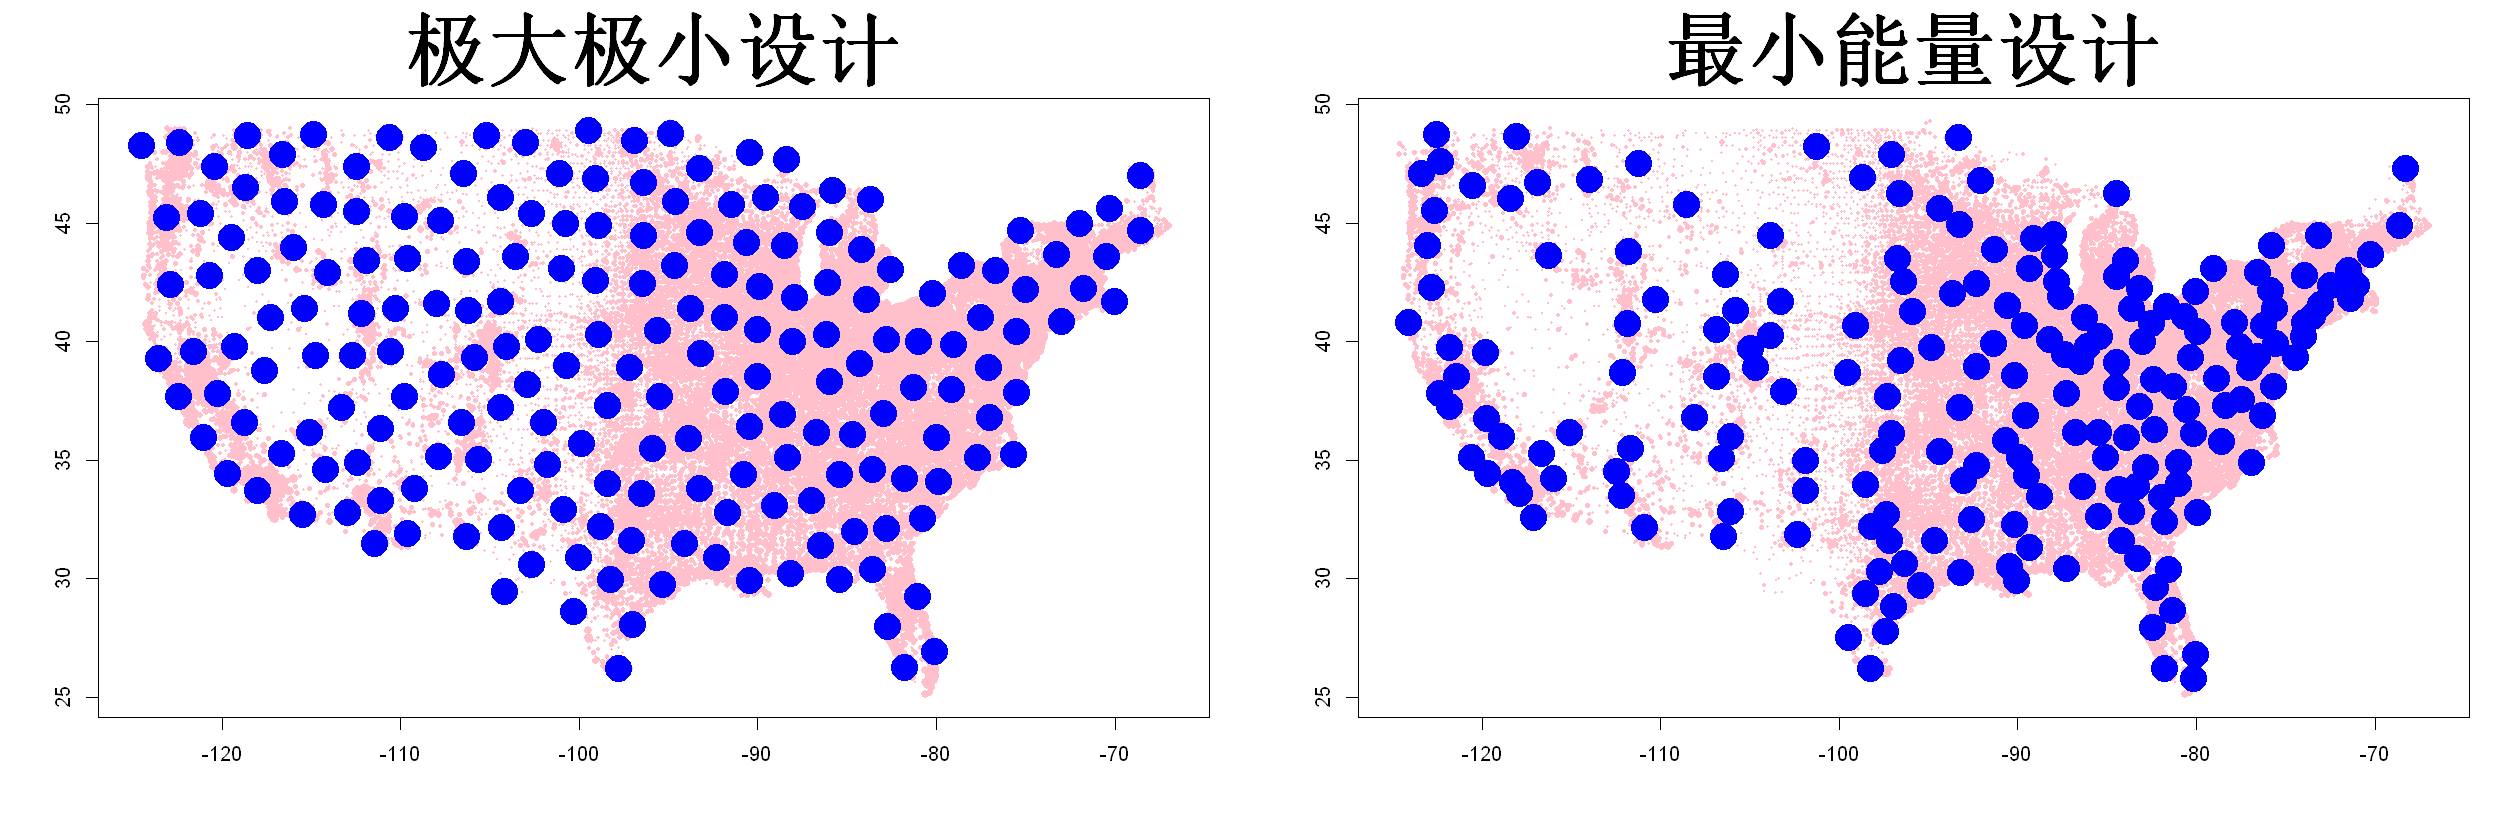

In [24]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.22-CAND.csv")||!file.exists("data/4.22-D.csv")||!file.exists("data/4.22-para.csv")){
  library(mined)
  library(zipcodeR)
  dat=na.omit(zip_code_db[,c(9,8,14)])
  ind=(dat[,2]<52 & dat[,2]>25)
  dat=dat[ind,]
  CAND=as.matrix(dat[,1:2])
  y=dat[,3]
  sizecode=.5+5*sqrt(y)/max(sqrt(y))
  D=SelectMinED(candidates=CAND,candlf=log(y),n=200,s=1)$points # 200x2
  library(maximin)
  p=2
  D0=matrix(CAND[sample(1:dim(CAND)[1],1),],nrow=1,ncol=p)
  D2=CAND[maximin.cand(199,Xcand=CAND,Xorig=D0)$inds,] # 199x2
  D2=rbind(D0,D2) # 200x2
  sizecode=.25+log(y+1)/max(log(y+1))
  m.CAND=cbind(CAND)
  write.csv(m.CAND,file="data/4.22-CAND.csv",row.names=FALSE)
  m.D=cbind(D2,D)
  colnames(m.D)=c("D2.lng","D2.lat","D.1","D.2")
  write.csv(m.D,file="data/4.22-D.csv",row.names=FALSE)
  m.para=cbind(sizecode=sizecode)
  write.csv(m.para,file="data/4.22-para.csv",row.names=FALSE)
}

CAND=as.matrix(read.csv("data/4.22-CAND.csv"))
df_D2=read.csv("data/4.22-D.csv")
D2=as.matrix(df_D2[,c("D2.lng","D2.lat")])
D=as.matrix(df_D2[,c("D.1","D.2")])
para=read.csv("data/4.22-para.csv")
sizecode=para$sizecode

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,2))
plot(CAND,cex=sizecode,pch=16,col="pink",xlab="",ylab="",main="极大极小设计",cex.main=4)
points(D2,pch=16,col="blue",cex=3)
plot(CAND,cex=sizecode,pch=16,col="pink",xlab="",ylab="",main="最小能量设计",cex.main=4)
points(D,pch=16,col="blue",cex=3)
par(mfrow=c(1,1))

> **图 4.24**：左图展示初始 20 次试验的最大投影设计点（红色）叠加在香蕉形后验分布上。右图展示经过四步退火处理后依次添加得到的 80 个最小能量设计点（蓝色）。

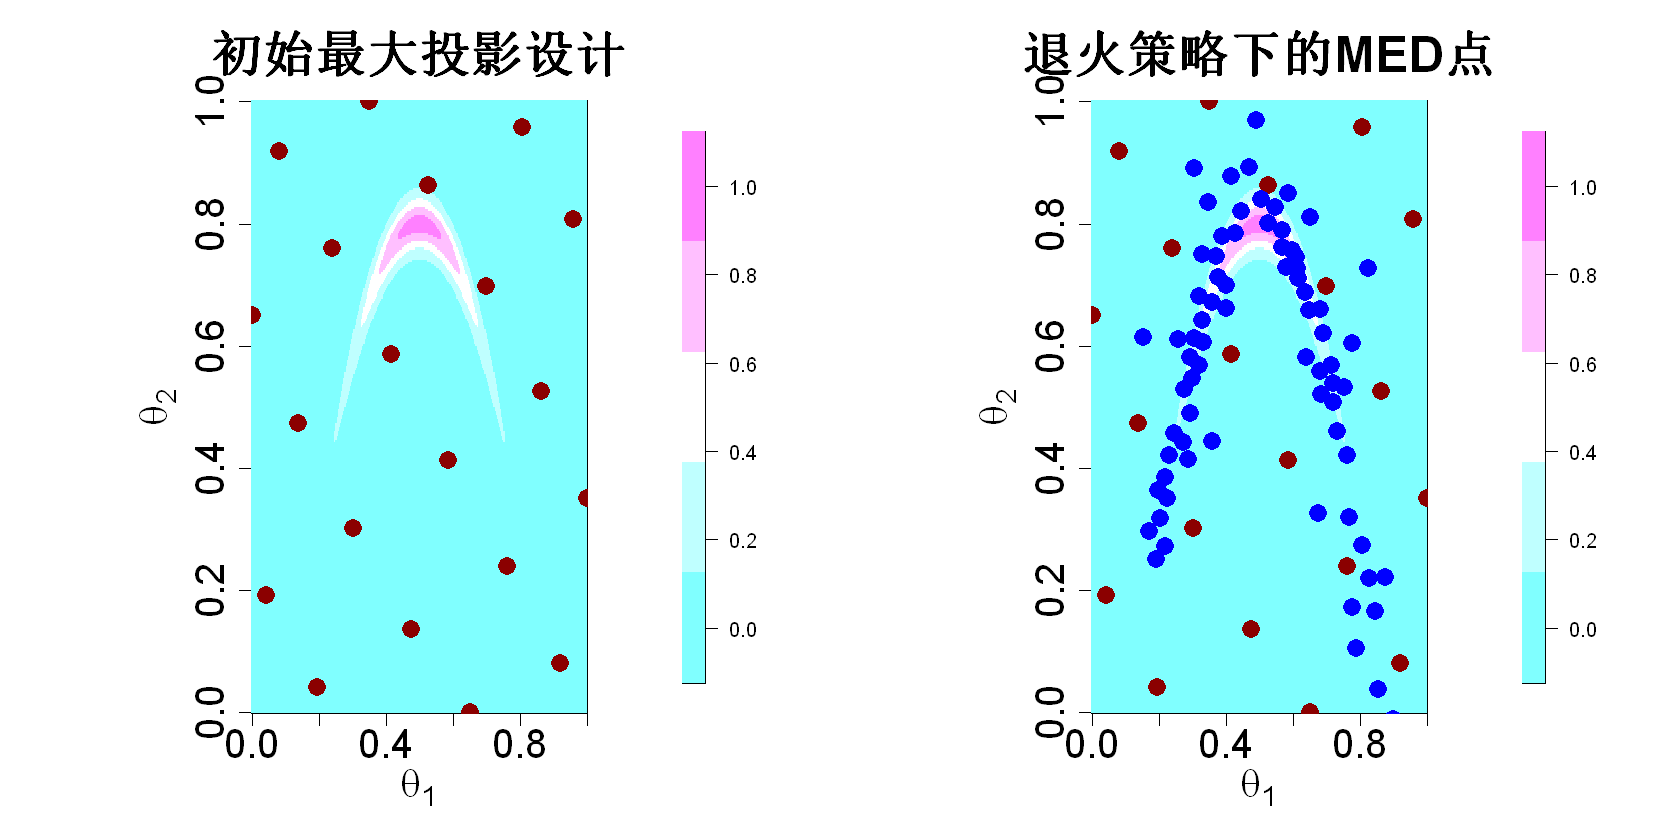

In [25]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.24-fc.csv")||!file.exists("data/4.24-p.csv")||!file.exists("data/4.24-ini.csv")||!file.exists("data/4.24-cand.csv")){
  logf=function(para){
    l1=-40
    u1=40
    l2=-25
    u2=10
    x1=l1+(u1-l1)*para[1]
    x2=l2+(u2-l2)*para[2]
    val=-.5*(x1^2/100+(x2+.03*x1^2-3)^2)
    return(val)
  }
  N.plot=300
  p1=seq(0,1,length.out=N.plot) # 300x1
  p2=seq(0,1,length.out=N.plot) # 300x1
  fc=matrix(0.0,N.plot,N.plot) # 300x300
  for(i in 1:N.plot){
    for(j in 1:N.plot){
      fc[i,j]=exp(logf(c(p1[i],p2[j])))
    }
  }
  set.seed(8)
  p=2;n=20
  library(MaxPro)
  ini=MaxPro(MaxProLHD(n,p)$Design)$Design # 20x2
  library(mined)
  res=mined(ini,logf,K_iter=5)
  D=res$points
  cand=res$cand # 100x2
  ind=match(ini[,1],cand[,1])
  cand=cand[-ind,] # 80x2
  m.fc=cbind(fc)
  colnames(m.fc)=c(paste0("fc.",1:N.plot))
  write.csv(m.fc,file="data/4.24-fc.csv",row.names=FALSE)
  m.p=cbind(p1=p1,p2=p2)
  write.csv(m.p,file="data/4.24-p.csv",row.names=FALSE)
  m.ini=cbind(ini)
  colnames(m.ini)=c(paste0("ini.",1:2))
  write.csv(m.ini,file="data/4.24-ini.csv",row.names=FALSE)
  m.cand=cbind(cand)
  colnames(m.cand)=c(paste0("cand.",1:2))
  write.csv(m.cand,file="data/4.24-cand.csv",row.names=FALSE)
}

df_fc=read.csv("data/4.24-fc.csv")
fc=as.matrix(df_fc)
df_p=read.csv("data/4.24-p.csv")
p1=df_p$p1;p2=df_p$p2
ini=as.matrix(read.csv("data/4.24-ini.csv"))
cand=as.matrix(read.csv("data/4.24-cand.csv"))

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,5))
par(mfrow=c(1,2))
library(fields)
imagePlot(p1,p2,fc,xlab=expression(theta[1]),ylab=expression(theta[2]),col=cm.colors(5),main="初始最大投影设计",cex.main=2.5,cex.lab=2,cex.axis=2)
points(ini,pch=16,col="darkred",cex=2)
imagePlot(p1,p2,fc,xlab=expression(theta[1]),ylab=expression(theta[2]),col=cm.colors(5),main="退火策略下的MED点",cex.main=2.5,cex.lab=2,cex.axis=2)
points(ini,pch=16,col="darkred",cex=2)
points(cand,pch=16,col="blue",cex=2)
par(mfrow=c(1,1))

> **图 4.25**：采用数值积分（绿色）、基于 100 点最小能量设计的基于试验设计的插值技术方法（蓝色）以及采样量为 10000 的自适应梅特罗波利斯算法（红色）得到的香蕉形后验分布的边缘后验密度。

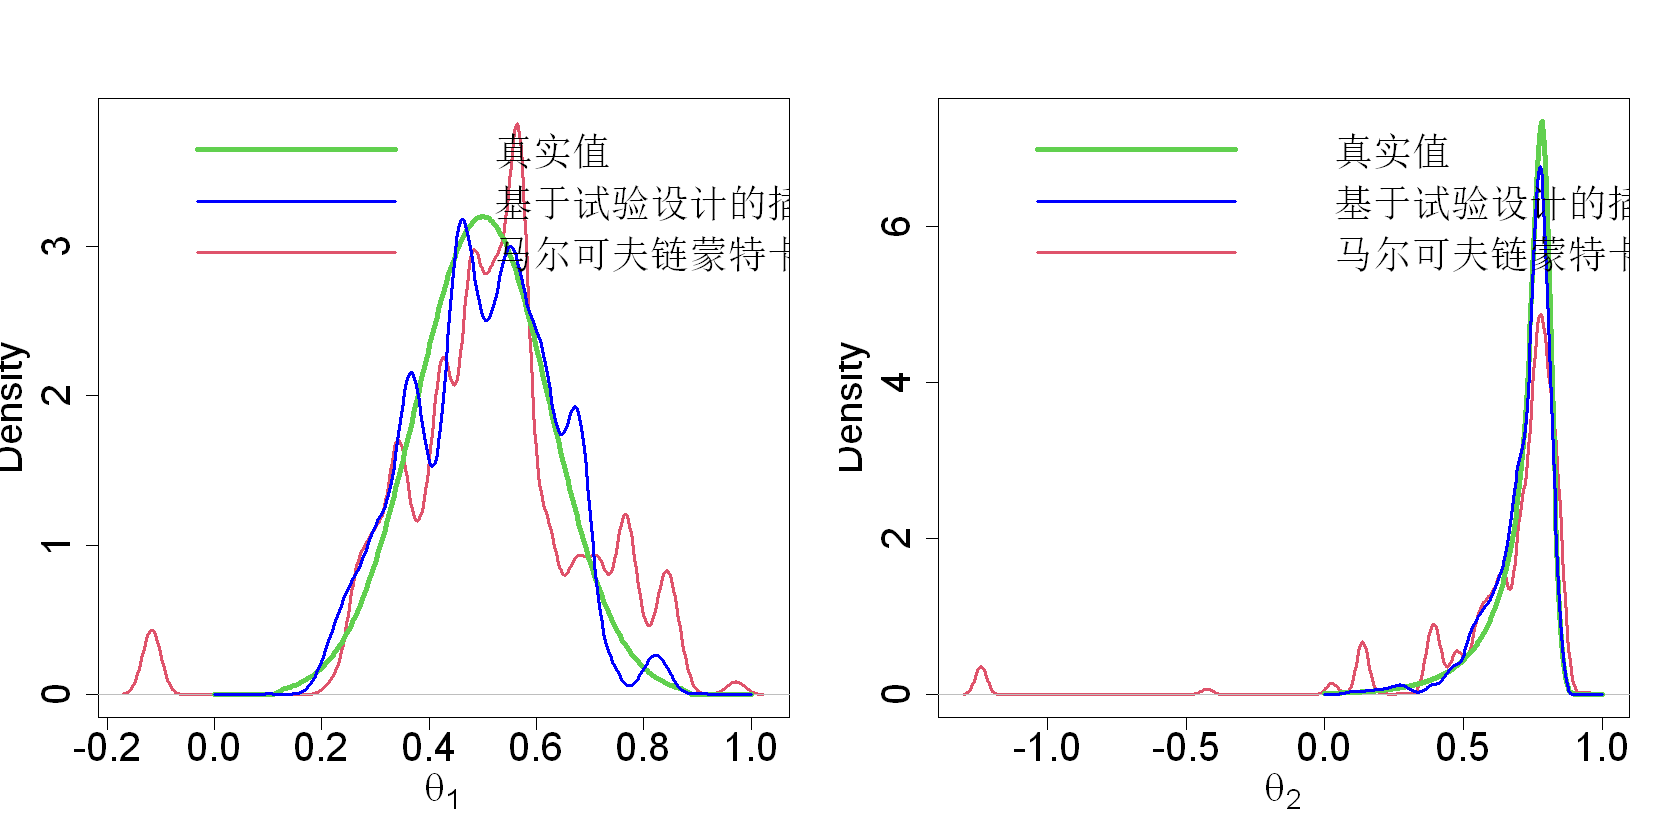

In [29]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.25-f.csv")||!file.exists("data/4.25-theta.csv")){
  logf=function(para){
    l1=-40
    u1=40
    l2=-25
    u2=10
    x1=l1+(u1-l1)*para[1]
    x2=l2+(u2-l2)*para[2]
    val=-.5*(x1^2/100+(x2+.03*x1^2-3)^2)
    return(val)
  }
  nlogh=function(para) -logf(para)
  h=function(para) exp(-nlogh(para))
  target=function(para) .5*logf(para)
  N.plot=300
  p1=seq(0,1,length.out=N.plot)
  p2=seq(0,1,length.out=N.plot)
  set.seed(8)
  p=2;n=20
  library(MaxPro)
  ini=MaxPro(MaxProLHD(n,p)$Design)$Design
  library(mined)
  res=mined(ini,target,K_iter=5)
  D=res$points
  cand=res$cand
  nu=cand
  hev=apply(nu,1,h)
  G.m=function(para)
  {
    A=nu%*%diag(sqrt(1/para))
    A=as.matrix(dist(A,diag=TRUE,upper=TRUE))
    return(exp(-.5*A^2))
  }
  exp1=function(e) exp(-.5*sum(e^2/sigma2))
  g=function(gamma)
  {
    A=t(t(nu)-gamma)
    vec=apply(A,1,exp1)
    return(vec)
  }
  wmscv.sigma=function(para)
  {
    G=G.m(para)
    Ginv=solve(G+.0001*diag(dim(G)[1]))
    di=diag(Ginv)
    cv=c(Ginv%*%sqrt(hev))/di
    val=mean(di*cv^2)
    return(log(val))
  }
  ini=(median(dist(nu)))^2/2
  sigma2=optim(rep(ini,p),wmscv.sigma,lower=rep(ini/100,p),upper=rep(100*ini,p),method="L-BFGS-B")$par
  sigma2
  Sigma=diag(sigma2)
  s=sqrt(diag(Sigma))
  B=nu%*%diag(1/s)
  B=as.matrix(dist(B,diag=TRUE,upper=TRUE))
  G=exp(-.5*B^2)
  Ginv=solve(G+.0001*diag(dim(G)[1]))
  coef=Ginv%*%sqrt(hev)
  G2=exp(-.25*B^2)
  denom=pi*prod(s)*as.numeric(t(coef)%*%G2%*%coef)
  Sigma.inv=diag(1/sigma2)
  m=dim(nu)[1]
  M=array(0,dim=c(m,m,p))
  for(k in 1:p) M[,,k]=outer(nu[,k],nu[,k],"+")/2
  d=outer(c(coef),c(coef),"*")*G2
  denk=function(theta,k){
    num=sum(d*dnorm(theta,M[,,k],s[k]/sqrt(2)))
    return(num/sum(d))
  }
  den=matrix(0,nrow=N.plot,ncol=p)
  v=cbind(p1,p2)
  for(k in 1:p) den[,k]=apply(cbind(v[,k]),1,denk,k=k)
  # 通过数值积分计算精确密度
  library(cubature)
  denom=adaptIntegrate(h,c(0,0),c(1,1))$int
  h1=function(theta1) apply(cbind(theta1,theta2),1,h)
  val=p2
  for(i in 1:N.plot)
  {
    theta2=p2[i]
    val[i]=integrate(h1,0,1)$val
  }
  exact=matrix(0,nrow=N.plot,ncol=p)
  exact[,2]=val/denom
  h2=function(theta2) apply(cbind(theta1,theta2),1,h)
  val=p1
  for(i in 1:N.plot)
  {
    theta1=p1[i]
    val[i]=integrate(h2,0,1)$val
  }
  exact[,1]=val/denom
  # MCMC
  library(adaptMCMC)
  s=(2.4/sqrt(2))^2*diag(p)
  out=MCMC(logf,n=10000,init=rep(.5,p),scale=s,adapt=TRUE,acc.rate=.05)
  theta=out$samples
  m.f=cbind(p1,p2,exact,den)
  colnames(m.f)=c("p1","p2",paste0("exact.",1:p),paste0("den.",1:p))
  write.csv(m.f,file="data/4.25-f.csv",row.names=FALSE)
  m.theta=cbind(theta)
  colnames(m.theta)=c(paste0("theta.",1:p))
  write.csv(m.theta,file="data/4.25-theta.csv",row.names=FALSE)
}

df_f=read.csv("data/4.25-f.csv")
p1=df_f$p1;p2=df_f$p2
exact=as.matrix(df_f[,paste0("exact.",1:2)])
den=as.matrix(df_f[,paste0("den.",1:2)])
theta=as.matrix(read.csv("data/4.25-theta.csv"))
v=cbind(p1,p2)

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
fac=c(1.2,1)
k=1
u=max(c(den[,k],exact[,k]))*fac[k]
plot(density(theta[,k]),type="l",col=2,lwd=3,ylim=c(0,u),lty=1,main="",xlab=expression(theta[1]),cex.lab=2,cex.axis=2)
lines(v[,k],exact[,k],lwd=4,col=3,lty=1)
lines(v[,k],den[,k],col="blue",lwd=3)
legend("topleft",col=c(3,"blue",2),lwd=c(4,3,3),legend=c("真实值","基于试验设计的插值技术方法","马尔可夫链蒙特卡洛方法"),bty="n",cex=2)
k=2
u=max(c(den[,k],exact[,k]))*fac[k]
plot(density(theta[,k]),type="l",col=2,lwd=3,ylim=c(0,u),lty=1,main="",xlab=expression(theta[2]),cex.lab=2,cex.axis=2)
lines(v[,k],exact[,k],lwd=4,col=3,lty=1)
lines(v[,k],den[,k],col="blue",lwd=3)
legend("topleft",col=c(3,"blue",2),lwd=c(4,3,3),legend=c("真实值","基于试验设计的插值技术方法","马尔可夫链蒙特卡洛方法"),bty="n",cex=2)
par(mfrow=c(1,1))

> **图 4.26** 左图展示了通过约束最小能量设计法得到的 2340 个候选点。右图展示了 925 个可行候选点。

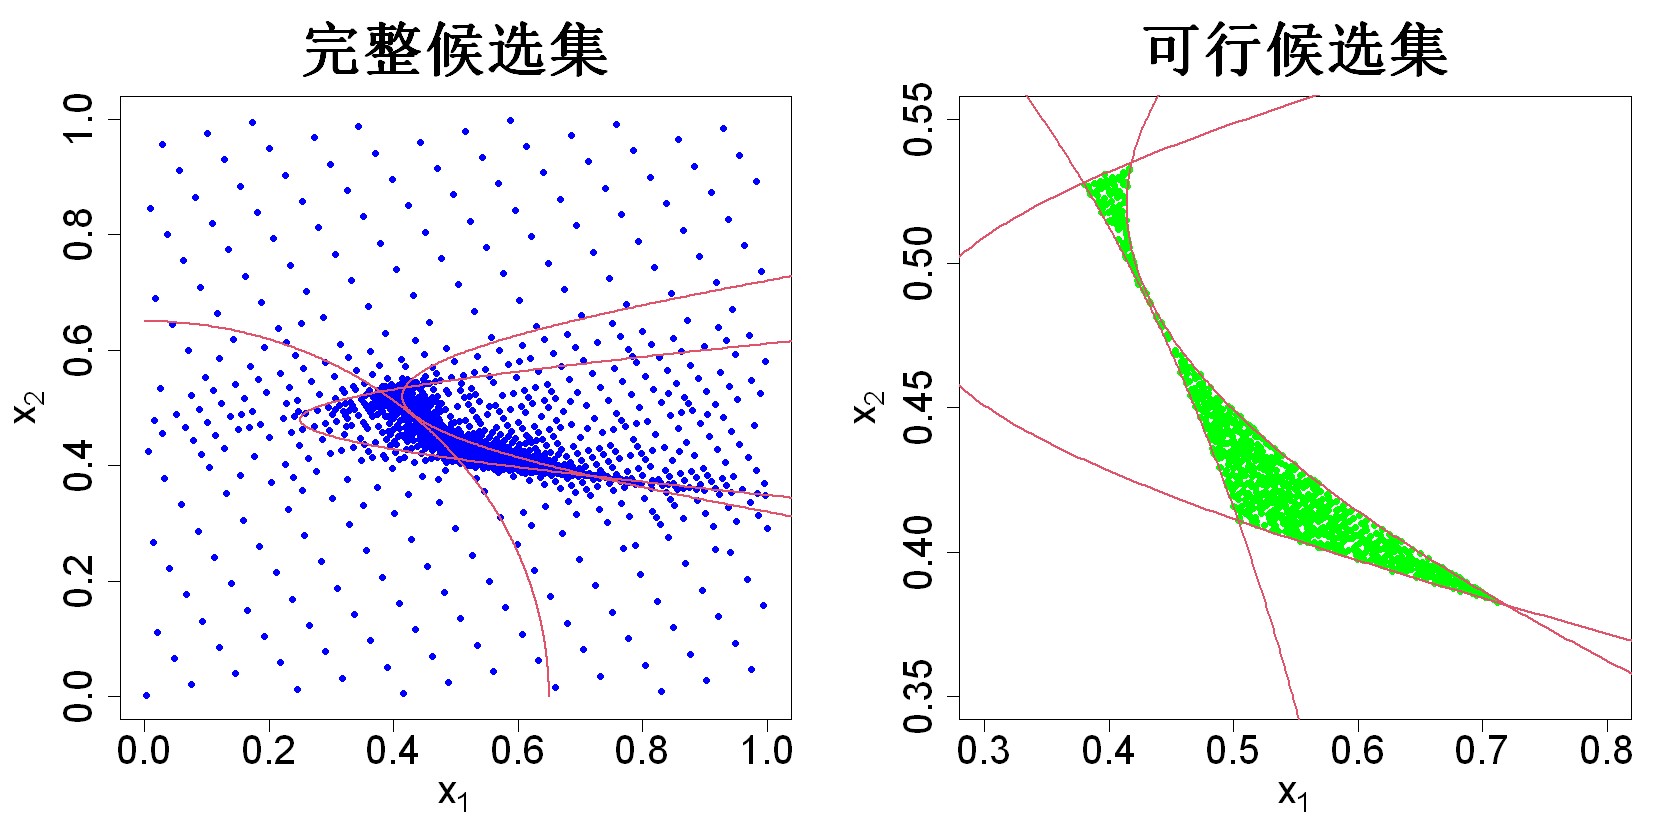

In [30]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.26-cand.csv")||!file.exists("data/4.26-feasible.csv")||!file.exists("data/4.26-x.csv")){
  constraint=function(x){
    c1=(x[1]-sqrt(50*(x[2]-0.52)^2+2)+1)
    c2=(sqrt(120*(x[2]-0.48)^2+1)-0.75-x[1])
    c3=(0.65^2-x[1]^2-x[2]^2)
    return(c(c1,c2,c3))
  }
  # 定义约束等值线
  x1=x2=matrix(NA,nrow=3,ncol=1001)
  x2.seq=seq(0,1,length.out=1001)
  x2[1,]=x2.seq
  x1[1,]=sqrt(50*(x2.seq-0.52)^2+2)-1
  x2[2,]=x2.seq
  x1[2,]=sqrt(120*(x2.seq-0.48)^2+1)-0.75
  x2[3,]=x2.seq
  x1[3,]=sqrt(0.65^2-x2.seq^2)
  contour=list(x1=x1,x2=x2)
  # 对数距离函数
  logdis=function(x,s=2){
    if(s>0) length(x)/s*log(sum(abs(x)^s)) else sum(log(abs(x)))
  }
  # 一次一个点的贪心算法实现 MED
  mined.seq=function(n,cand,cand.lf,s=2,return.obj=F){
    N=nrow(cand)
    if(n>N) stop(message("Not enough candidate points!"))
    p=ncol(cand)
    idx=which.max(cand.lf)
    xi=c(idx)
    val=NULL
    for(i in 2:n){
      cand.dist=cand-rep(1,N)%*%t(cand[idx,])
      val=cbind(val,0.5*cand.lf[idx]+0.5*cand.lf+apply(cand.dist,1,logdis,s=s))
      idx=which.max(apply(val,1,min))
      xi=c(xi,idx)
    }
    if(return.obj){
      val=val[xi,]
      val=cbind(val,c(val[n,],-Inf))
      obj=min(val[upper.tri(val)])
      return(list(idx=xi,obj=obj))
    }
    return(xi)
  }
  comined=function(n,p,tau,constraint,n.aug,auto.scale=F,s=2,visualization=F,visualization.params=list()){
    # 初始化样本
    samp=Lattice(n*n.aug,p)
    min.dist=min(dist(samp))
    min.ddist=Inf # 维度最小距离
    for(i in 1:p){
      ddist=min(dist(samp[,i]))
      if(ddist<min.ddist) min.ddist=ddist
    }
    samp.gval=matrix(t(apply(samp,1,constraint)),nrow=nrow(samp))
    # 若启用自动缩放则计算尺度参数
    scale=rep(1,ncol(samp.gval))
    if(auto.scale) scale=apply(samp.gval,2,mad,center=0)
    # 寻找第一组最小能量设计点
    samp.lf=apply(samp.gval,1,function(x) sum(pnorm(-tau[2]*x/scale,log.p=TRUE)))
    med.op=mined.seq(n,samp,samp.lf,s=s,return.obj=TRUE)
    samp.med=samp[med.op$idx,]
    if(visualization){
      vparams=list(unit.scale=FALSE,contour=NULL)
      vparams[(nm<-names(visualization.params))]=visualization.params
      xlim=ylim=NULL
      if(vparams$unit.scale) xlim=ylim=c(0,1)
      plot(samp,col="green",pch=18,cex=0.75,xlim=xlim,ylim=ylim,xlab="",ylab="")
      points(samp.med,col="red",pch=16,cex=1)
      if(!is.null(vparams$contour)){
        contours=vparams$contour
        for(l in 1:nrow(contour$x1)){
          lines(contour$x1[l,],contour$x2[l,],lty=2)
        }
      }
    }
    for(k in 3:length(tau)){
      min.dist=min.dist/2
      min.ddist=min.ddist/2
      no.decimal=attr(regexpr("(?<=\\.)0+",format(min.ddist,scientific=F),perl=TRUE),"match.length")+1
      # 样本扩增
      samp.med.dist=as.matrix(dist(samp.med))
      samp.aug=NULL
      for(i in 1:n){
        nn.idx=order(samp.med.dist[i,])[2:(n.aug+1)]
        samp.aug=rbind(samp.aug,0.5*(samp.med[nn.idx,]+rep(1,n.aug)%*%t(samp.med[i,])))
        samp.aug=rbind(samp.aug,0.5*(3*samp.med[nn.idx,]-rep(1,n.aug)%*%t(samp.med[i,])))
      }
      # 移除重复样本
      samp.aug.rep=round(samp.aug,digits=no.decimal)
      samp.aug.dp=duplicated(samp.aug.rep)
      samp.aug=samp.aug[!samp.aug.dp,]
      # 移除越界样本
      samp.aug.out=apply(samp.aug,1,function(x) (any(x<0)|any(x>1)))
      samp.aug=samp.aug[!samp.aug.out,]
      # 因数值问题移除邻近点
      no.aug=nrow(samp.aug)
      samp.rep=rbind(samp.aug,samp)
      samp.rep=round(samp.rep,digits=no.decimal)
      samp.rep.dp=duplicated(samp.rep,fromLast=TRUE)
      samp.aug=samp.aug[!(samp.rep.dp[1:no.aug]),]
      if(nrow(samp.aug)>0){
        # 计算扩增样本的约束值
        samp.aug.gval=matrix(t(apply(samp.aug,1,constraint)),nrow=nrow(samp.aug))
        # 将扩增样本与原始样本合并
        samp=rbind(samp,samp.aug)
        samp.gval=rbind(samp.gval,samp.aug.gval)
      }
      # 寻找最小能量设计点
      if(auto.scale) scale=apply(samp.gval,2,mad,center=0)
      samp.lf=apply(samp.gval,1,function(x) sum(pnorm(-tau[k]*x/scale,log.p=TRUE)))
      if(s==0){
        hp=floor(p/2)
        nl=sqrt((min.dist^2-min.ddist^2*hp)/(p-hp))
        min.logdis=logdis(c(rep(min.ddist,hp),rep(nl,(p-hp))),s=s)
      } else {
        min.logdis=logdis(rep(min.dist/sqrt(p),p),s=s)
      }
      samp.lf.cv=sort(samp.lf,decreasing=TRUE)[n]+2.5*min.logdis
      samp.cand.idx=(samp.lf>samp.lf.cv)
      samp.cand=samp[samp.cand.idx,]
      samp.cand.lf=samp.lf[samp.cand.idx]
      med.op=mined.seq(n,samp.cand,samp.cand.lf,s=s,return.obj=TRUE)
      samp.med=samp.cand[med.op$idx,]
      if(visualization){
        plot(samp.cand,col="green",pch=18,cex=0.75,xlim=xlim,ylim=ylim,xlab="",ylab="")
        points(samp.med,col="red",pch=16,cex=1)
        if(!is.null(vparams$contour)){
          contour=vparams$contour
          for(l in 1:nrow(contour$x1)){
            lines(contour$x1[l,],contour$x2[l,],lty=2)
          }
        }
      }
    }
    samp.med.lf=samp.cand.lf[med.op$idx]
    feasible.idx=!(apply(samp.gval,1,function(x) any(x>0)))
    return(list(med=samp.med,
                med.lf=samp.med.lf,
                cand=samp,
                cand.lf=samp.lf,
                cand.min.dist=min.dist,
                cand.min.ddist=min.ddist,
                feasible.idx=feasible.idx))
  }
  library(mined)
  set.seed(20210329)
  tau=c(0,exp(c(1:7)),1e6)
  comined.output=comined(n=53,p=2,tau=tau,constraint=constraint,n.aug=5,auto.scale=F,s=2,visualization=F,visualization.params=list(unit.scale=TRUE,contour=contour))
  cand=comined.output$cand # 完整候选集
  cand.feasible=comined.output$cand[comined.output$feasible.idx,] # 可行候选集
  m.x=cbind(t(x1),t(x2))
  colnames(m.x)=c(paste0("x1.",1:3),paste0("x2.",1:3))
  write.csv(m.x,file="data/4.26-x.csv",row.names=FALSE)
  m.cand=cbind(cand)
  colnames(m.cand)=c("cand.1","cand.2")
  write.csv(m.cand,file="data/4.26-cand.csv",row.names=FALSE)
  m.feasible=cbind(cand.feasible)
  colnames(m.feasible)=c("feasible.1","feasible.2")
  write.csv(m.feasible,file="data/4.26-feasible.csv",row.names=FALSE)
}

df_x=read.csv("data/4.26-x.csv")
x1=t(as.matrix(df_x[,paste0("x1.",1:3)]))
x2=t(as.matrix(df_x[,paste0("x2.",1:3)]))
cand=as.matrix(read.csv("data/4.26-cand.csv"))
feasible=as.matrix(read.csv("data/4.26-feasible.csv"))

options(repr.plot.width=14,repr.plot.height=7)
par(mar=c(5,5,4,2))
par(mfrow=c(1,2))
plot(cand,col="blue",pch=16,cex=.75,xlim=c(0,1),ylim=c(0,1),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="完整候选集",cex.main=3)
for(i in 1:3) lines(x1[i,],x2[i,],col=2,lwd=2)
plot(feasible,col="green",pch=16,cex=.75,xlim=c(.3,.8),ylim=c(.35,.55),cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="可行候选集",cex.main=3)
for(i in 1:3) lines(x1[i,],x2[i,],col=2,lwd=2)
par(mfrow=c(1,1))

> **图 4.27** 多精度仿真算例设计的散点图矩阵。

n: 118 
多精度模型的均方根误差： 0.05356237 
单精度模型的均方根误差： 0.4203645 


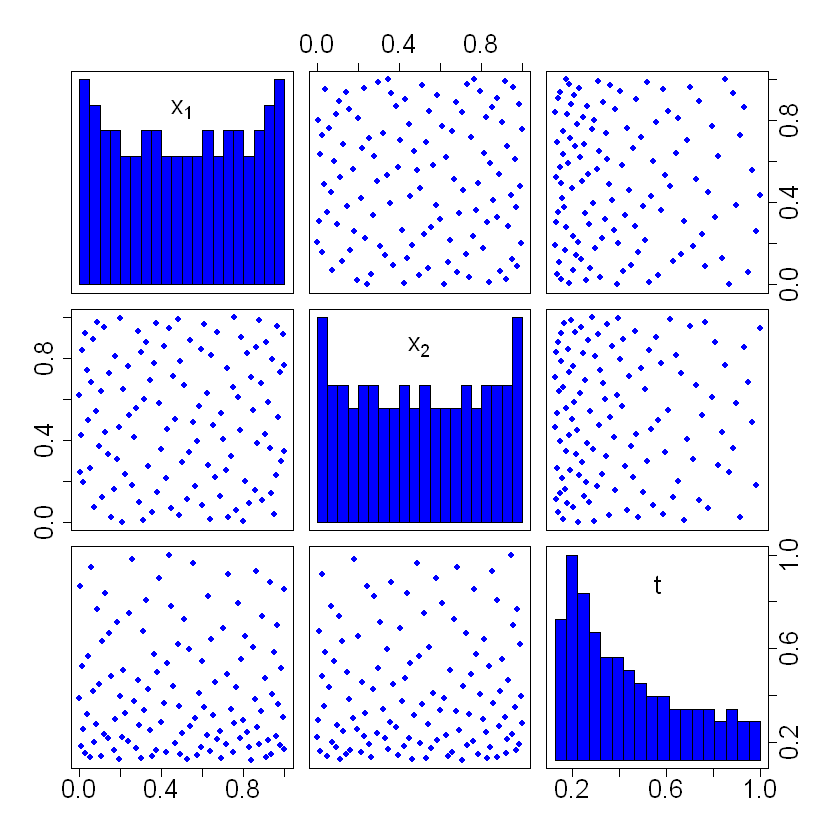

In [31]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.27-D.csv")||!file.exists("data/4.27-para.csv")){
  f=function(u){
    x=u[1:2]
    M=1/u[3]
    term1=(1-exp(-1/(2*x[2])))*(2300*x[1]^3+1900*x[1]^2+2092*x[1]+60)/(100*x[1]^3+500*x[1]^2+4*x[1]+20)
    term2=16*exp(-1.4*x[1])*cos(3.5*pi*x[2])
    val=term1+term2*u[3]
    return(val)
  }
  p=2
  Mt=2
  Mb=16
  lam=Mb/Mt
  nb=50
  nu=(nb*lam-1)/(lam*(nb-1))
  n=1+round(log(lam)/log(nu))
  u=((1:n)-1)/(n-1)
  M=Mt*(Mb/Mt)^u
  h=1/M
  h=sort(h/max(h))
  set.seed(1)
  library(SFDesign)
  library(MaxPro)
  D=maxpro.optim(maxproLHD(n,p+1)$design)$design
  D=D[order(D[,3]),]
  D[,3]=h
  MaxProMeasure(D)
  a=MaxProQQ(D)
  a$measure
  D=a$Design
  y=apply(D,1,f)
  # 生成测试点
  test=MaxProAugment(ExistDesign=D[,1:p],CandDesign=CandPoints(100*n,p),nNew=100)$Design[-(1:n),]
  true=apply(cbind(test,0),1,f)
  # 拟合式 (4.58) 中的模型
  OKfit=function(D,y,ini,nug=10^(-6)){
    n=length(y)
    if(!is.matrix(D)) D=matrix(D,ncol=1)
    p=dim(D)[2]-1
    r=function(x,theta){
      theta0=theta[1:p]
      theta1=theta[(p+1):(2*p)]
      gam=theta[2*p+1]
      lam=theta[2*p+2]
      if(p>1){
        A=sweep(D[,1:p],2,x[1:p],"-")
        g0=exp(-apply((A%*%diag(1/theta0))^2,1,sum))
        g1=exp(-apply((A%*%diag(1/theta1))^2,1,sum))
        b=exp(-((D[,p+1]-x[p+1])/gam)^2)-exp(-((D[,p+1])/gam)^2)-exp(-((x[p+1])/gam)^2)+1
        g=g0+lam*g1*b
      }else{
        g0=exp(-((D[,1]-x[1])/theta0)^2)
        g1=exp(-((D[,1]-x[1])/theta1)^2)
        b=pmin(D[,2],x[2])
        g=g0+lam*g1*b
      }
      return(g)
    }
    ML=function(theta){
      R=apply(D,1,r,theta)+nug*diag(n)
      L=chol(R)
      a=forwardsolve(t(L),one)
      b=forwardsolve(t(L),y)
      mu=sum(a*b)/sum(a^2)
      nu2=1/n*sum((b-mu*a)^2)
      nu2=max(nu2,10^(-15))
      val=log(nu2)+2*mean(log(diag(L)))
      return(val)
    }
    one=rep(1,n)
    a.opt=optim(ini,ML,lower=ini/10,upper=10*ini,method="L-BFGS-B",control=list("maxit"=100))
    theta=a.opt$par
    R=apply(D,1,r,theta)+nug*diag(n)
    L=chol(R)
    a=forwardsolve(t(L),one)
    b=forwardsolve(t(L),y)
    mu=sum(a*b)/sum(a^2)
    nu2=1/n*sum((b-mu*a)^2)
    return(list(mu=mu,nu2=nu2,theta=theta,L=L,a=a,b=b,D=D))
  }
  OKpredict=function(obj,new){
    mu=obj$mu
    nu2=obj$nu2
    theta=obj$theta
    L=obj$L
    a=obj$a
    b=obj$b
    D=obj$D
    r=function(x,theta){
      theta0=theta[1:p]
      theta1=theta[(p+1):(2*p)]
      gam=theta[2*p+1]
      lam=theta[2*p+2]
      if(p>1){
        A=sweep(D[,1:p],2,x[1:p],"-")
        g0=exp(-apply((A%*%diag(1/theta0))^2,1,sum))
        g1=exp(-apply((A%*%diag(1/theta1))^2,1,sum))
        b=exp(-((D[,p+1]-x[p+1])/gam)^2)-exp(-((D[,p+1])/gam)^2)-exp(-((x[p+1])/gam)^2)+1
        g=g0+lam*g1*b
      }else{
        g0=exp(-((D[,1]-x[1])/theta0)^2)
        g1=exp(-((D[,1]-x[1])/theta1)^2)
        b=pmin(D[,2],x[2])
        g=g0+lam*g1*b
      }
      return(g)
    }
    ok=function(x,para){
      d=forwardsolve(t(L),r(x,para))
      t1=mu+sum(d*(b-mu*a))
      t2=sqrt(nu2)*sqrt(max(1-sum(d^2)+(1-sum(d*a))^2/sum(a^2),0))
      return(c(t1,t2))
    }
    pred=apply(cbind(new),1,ok,para=theta)
    return(list(mean=pred[1,],sd=pred[2,]))
  }
  a=OKfit(D,y,ini=rep(1,2*p+2))
  pred=OKpredict(a,cbind(test,0))$mean
  rmse=sqrt(mean((pred-true)^2))
  # 单精度仿真
  D1=maxpro.optim(maxproLHD(nb,p)$design)$design
  y1=apply(cbind(D1,1/Mb),1,f)
  library(rkriging)
  a1=Fit.Kriging(D1,y1,kernel.parameters=list(type="Gaussian"))
  pred1=Predict.Kriging(a1,test)$mean
  rmse1=sqrt(mean((pred1-true)^2))
  m.D=cbind(D)
  colnames(m.D)=c(paste0("D.",1:3))
  write.csv(m.D,file="data/4.27-D.csv",row.names=FALSE)
  m.para=cbind(n=n,rmse=rmse,rmse1=rmse1)
  write.csv(m.para,file="data/4.27-para.csv",row.names=FALSE)
}

D=as.matrix(read.csv("data/4.27-D.csv"))
para=read.csv("data/4.27-para.csv")
n=para$n;rmse=para$rmse;rmse1=para$rmse1

cat("n:",n,"\n")
cat("多精度模型的均方根误差：",rmse,"\n")
cat("单精度模型的均方根误差：",rmse1,"\n")

options(repr.plot.width=7,repr.plot.height=7)
library(car)
scatterplotMatrix(D,diagonal=list(method="histogram",breaks=15),smooth=FALSE,regLine=FALSE,pch=16,var.labels=c(expression(x[1]),expression(x[2]),"t"),cex.axis=2)